In [ ]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

entity = "18920011663-king-s-college-london"
project = "World_Model_Curriculum_Learning"          
prefixes = ["CL_WM_without_editing", "CL_WM_without_RB", "CL_WM*"]           
# Define the keys for the data you want to extract
step_key = "curriculum_step"
metric_name = "final_task_performance"
api = wandb.Api(timeout=60)
runs = api.runs(f"{entity}/{project}")
step_min, step_max = 0, 50  # Step range to display

In [ ]:
def load_group(prefix):
    runs = api.runs(f"{entity}/{project}")
    selected_runs = [run for run in runs if run.name.startswith(prefix)]
    print(f"\nGroup '{prefix}': Found {len(selected_runs)} runs")

    data_frames = []
    for run in selected_runs:
        try:
            history = run.history()
            if metric_name not in history.columns or step_key not in history.columns:
                print(f"Skipping {run.name}: missing '{metric_name}' or '{step_key}'")
                continue
            df = history[[step_key, metric_name]].dropna()
            df = df.groupby(step_key).mean().reset_index()
            df.rename(columns={metric_name: run.name}, inplace=True)
            data_frames.append(df.set_index(step_key))
            print(f"  Loaded {run.name}")
        except Exception as e:
            print(f"  Error loading {run.name}: {e}")

    if not data_frames:
        return None, None, None
    
    merged_df = pd.concat(data_frames, axis=1)
    mean = merged_df.mean(axis=1)
    std = merged_df.std(axis=1)

    return merged_df.index, mean, std

plt.figure(figsize=(12, 6))

for prefix in prefixes:
    steps, mean, std = load_group(prefix)
    if steps is None:
        continue
    
    # Filter to only include step range 0 to 50
    step_mask = (steps >= step_min) & (steps <= step_max)
    steps_filtered = steps[step_mask]
    mean_filtered = mean[step_mask]
    std_filtered = std[step_mask]
    
    plt.plot(steps_filtered, mean_filtered, linewidth=2, label=f"{prefix} ")
    plt.fill_between(steps_filtered, mean_filtered - std_filtered, mean_filtered + std_filtered, alpha=0.2)

plt.xlabel(step_key)
plt.ylabel(metric_name)
plt.title(f"Comparison of Run Groups")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load CSV
csv_path = "logs/target_eval_log.csv"  # Adjust if necessary
df = pd.read_csv(csv_path)

# Create a continuous index for x-axis
df['global_index'] = range(1, len(df) + 1)

# Create plot
plt.figure(figsize=(14, 6))
plt.plot(df['global_index'], df['target_loss'], marker='o', markersize=3, linewidth=1, label='Target Loss')

# Identify phase boundaries and centers
unique_phases = df['phase'].unique()
phase_centers = []

for phase in unique_phases:
    phase_data = df[df['phase'] == phase]
    start_idx = phase_data['global_index'].min()
    end_idx = phase_data['global_index'].max()
    phase_centers.append((start_idx + end_idx) // 2)
    # Draw boundary line at end of each phase
    plt.axvline(x=end_idx, linestyle='dotted', color='gray')

# Place labels at the bottom
min_loss = df['target_loss'].min()
y_text = min_loss * 0.995  # slightly below the minimum loss on the plot

for center, phase in zip(phase_centers, unique_phases):
    plt.text(center, y_text, phase, rotation=0, ha='center', va='top', fontsize=10)

# Styling
plt.title('Target Task Loss Across Continual Learning Phases', fontsize=14)
plt.xlabel('Validation Index (Global)', fontsize=12)
plt.ylabel('Target Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/target_eval_log_compare_uniform.csv"
df = pd.read_csv(csv_path, header=None)
df.columns = ["seed", "mode", "phase", "transitions", "avg_target_loss"]

# Ensure numeric
df["transitions"] = pd.to_numeric(df["transitions"], errors="coerce")
df["avg_target_loss"] = pd.to_numeric(df["avg_target_loss"], errors="coerce")

# === 2. Split by order (first half = CL, second half = target task) ===
num_per_group = len(df) // 2
cl_df = df.iloc[:num_per_group]
target_df = df.iloc[num_per_group:]

# === 3. X-axis based on cumulative transitions ===
x = cl_df["transitions"].cumsum()
x_target = target_df["transitions"].cumsum()

# === 4. Plot ===
plt.figure(figsize=(9, 5))

# Curriculum Learning line
plt.plot(x, cl_df["avg_target_loss"], marker="o", color="royalblue",
         linewidth=2, label="Curriculum Learning (Minitasks)")
plt.scatter(x, cl_df["avg_target_loss"], color="royalblue", s=60, edgecolor="black")

# Target Task line
plt.plot(x_target, target_df["avg_target_loss"], marker="o", color="orange",
         linewidth=2, label="Direct Target Task Training")
plt.scatter(x_target, target_df["avg_target_loss"], color="orange", s=60, edgecolor="black")

# === 5. Annotate last values ABOVE the points ===
# Curriculum Learning
last_x_cl = x.iloc[-1]
last_y_cl = cl_df["avg_target_loss"].iloc[-1]
plt.text(last_x_cl, last_y_cl + 0.0002, f"{last_y_cl:.4f}", color="royalblue",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# Target Task
last_x_t = x_target.iloc[-1]
last_y_t = target_df["avg_target_loss"].iloc[-1]
plt.text(last_x_t, last_y_t + 0.0002, f"{last_y_t:.4f}", color="darkorange",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# === 6. Formatting ===
plt.xlabel("Transitions Collected")
plt.ylabel("Average Target Loss")
plt.title("Curriculum Learning vs Direct Target Task Training")
plt.xticks(x, [f"{int(v/1000)}k" for v in x], rotation=0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/target_eval_log_compare_random.csv"
df = pd.read_csv(csv_path, header=None)
df.columns = ["seed", "mode", "phase", "transitions", "avg_target_loss"]

# Ensure numeric
df["transitions"] = pd.to_numeric(df["transitions"], errors="coerce")
df["avg_target_loss"] = pd.to_numeric(df["avg_target_loss"], errors="coerce")

# === 2. Split by order (first half = CL, second half = target task) ===
num_per_group = len(df) // 2
cl_df = df.iloc[:num_per_group]
target_df = df.iloc[num_per_group:]

# === 3. X-axis based on cumulative transitions ===
x = cl_df["transitions"].cumsum()
x_target = target_df["transitions"].cumsum()

# === 4. Plot ===
plt.figure(figsize=(9, 5))

# Curriculum Learning line
plt.plot(x, cl_df["avg_target_loss"], marker="o", color="royalblue",
         linewidth=2, label="Curriculum Learning (Minitasks)")
plt.scatter(x, cl_df["avg_target_loss"], color="royalblue", s=60, edgecolor="black")

# Target Task line
plt.plot(x_target, target_df["avg_target_loss"], marker="o", color="orange",
         linewidth=2, label="Direct Target Task Training")
plt.scatter(x_target, target_df["avg_target_loss"], color="orange", s=60, edgecolor="black")

# === 5. Annotate last values ABOVE the points ===
# Curriculum Learning
last_x_cl = x.iloc[-1]
last_y_cl = cl_df["avg_target_loss"].iloc[-1]
plt.text(last_x_cl, last_y_cl + 0.0002, f"{last_y_cl:.4f}", color="royalblue",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# Target Task
last_x_t = x_target.iloc[-1]
last_y_t = target_df["avg_target_loss"].iloc[-1]
plt.text(last_x_t, last_y_t + 0.0002, f"{last_y_t:.4f}", color="darkorange",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# === 6. Formatting ===
plt.xlabel("Transitions Collected")
plt.ylabel("Average Target Loss")
plt.title("Curriculum Learning vs Direct Target Task Training")
plt.xticks(x, [f"{int(v/1000)}k" for v in x], rotation=0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/target_eval_log_compare_one_element.csv"
df = pd.read_csv(csv_path, header=None)
df.columns = ["seed", "mode", "phase", "transitions", "avg_target_loss"]

# Ensure numeric
df["transitions"] = pd.to_numeric(df["transitions"], errors="coerce")
df["avg_target_loss"] = pd.to_numeric(df["avg_target_loss"], errors="coerce")

# === 2. Split by order (first half = CL, second half = target task) ===
num_per_group = len(df) // 2
cl_df = df.iloc[:num_per_group]
target_df = df.iloc[num_per_group:]

# === 3. X-axis based on cumulative transitions ===
x = cl_df["transitions"].cumsum()
x_target = target_df["transitions"].cumsum()

# === 4. Plot ===
plt.figure(figsize=(9, 5))

# Curriculum Learning line
plt.plot(x, cl_df["avg_target_loss"], marker="o", color="royalblue",
         linewidth=2, label="Curriculum Learning (Minitasks)")
plt.scatter(x, cl_df["avg_target_loss"], color="royalblue", s=60, edgecolor="black")

# Target Task line
plt.plot(x_target, target_df["avg_target_loss"], marker="o", color="orange",
         linewidth=2, label="Direct Target Task Training")
plt.scatter(x_target, target_df["avg_target_loss"], color="orange", s=60, edgecolor="black")

# === 5. Annotate last values ABOVE the points ===
# Curriculum Learning
last_x_cl = x.iloc[-1]
last_y_cl = cl_df["avg_target_loss"].iloc[-1]
plt.text(last_x_cl, last_y_cl + 0.0002, f"{last_y_cl:.4f}", color="royalblue",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# Target Task
last_x_t = x_target.iloc[-1]
last_y_t = target_df["avg_target_loss"].iloc[-1]
plt.text(last_x_t, last_y_t + 0.0002, f"{last_y_t:.4f}", color="darkorange",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# === 6. Formatting ===
plt.xlabel("Transitions Collected")
plt.ylabel("Average Target Loss")
plt.title("Curriculum Learning vs Direct Target Task Training")
plt.xticks(x, [f"{int(v/1000)}k" for v in x], rotation=0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/results/target_eval_log_compare_patches_minitask.csv"
df = pd.read_csv(csv_path)

# 2. 分离 CL 和 Baseline
df_cl = df[df['mode'] == 'CL']
df_baseline = df[df['mode'] == 'Baseline']

# 3. 按 transitions 排序（保证 x 轴递增）
df_cl = df_cl.sort_values(by='transitions')
df_baseline = df_baseline.sort_values(by='transitions')

# 4. 画图
plt.figure(figsize=(8,6))

plt.plot(df_cl['transitions'], df_cl['avg_target_loss'],
         marker='o', label='Curriculum Learning (CL)', linewidth=2)

plt.plot(df_baseline['transitions'], df_baseline['avg_target_loss'],
         marker='s', label='Baseline', linewidth=2)

# 5. 图表格式美化
plt.xlabel("Transitions Used", fontsize=12)
plt.ylabel("Average Target Loss", fontsize=12)
plt.title("CL vs Baseline (3 target tasks)", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.legend(loc="upper right")

plt.show()



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============= 1. 读取 CSV 文件 =============
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/results/target_eval_log_compare_3_targets.csv"  # 你的路径
df = pd.read_csv(csv_path)

# ============= 2. 拆分 CL 和 Baseline =============
df_cl = df[df["mode"] == "CL"].sort_values("transitions")
df_baseline = df[df["mode"] == "Baseline"].sort_values("transitions")

# ============= 3. 设置专业风格 =============
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 4))

# 更专业的颜色
color_cl = "#1f77b4"       # 专业深蓝
color_base = "#ff7f0e"     # 专业橙色

# ============= 4. 绘图 =============
ax.plot(
    df_cl["transitions"], df_cl["avg_target_loss"],
    marker="o", linewidth=2.5, markersize=6,
    label="Curriculum Learning (CL)",
    color=color_cl
)

ax.plot(
    df_baseline["transitions"], df_baseline["avg_target_loss"],
    marker="s", linewidth=2.5, markersize=6,
    label="Baseline",
    color=color_base
)

# ============= 5. 坐标轴美化 =============
ax.set_xlabel("Transitions Used", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Target Loss", fontsize=14, fontweight="bold")

ax.set_title("CL vs Baseline Performance", fontsize=16, fontweight="bold")

# 更专业的科学计数法（如果需要）
ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

ax.tick_params(labelsize=12)

# ============= 6. 图例放在右侧，不遮挡曲线 =============
ax.legend(fontsize=13, loc="center left", bbox_to_anchor=(1.02, 0.5))

# ============= 7. 网格更淡，不喧宾夺主 =============
ax.grid(alpha=0.5)

# ============= 8. 紧凑布局 + 保存高清图 =============
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============= 1. 读取 CSV 文件 =============
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/results/target_eval_log_compare_6_targets.csv"  # 你的路径
df = pd.read_csv(csv_path)

# ============= 2. 拆分 CL 和 Baseline =============
df_cl = df[df["mode"] == "CL"].sort_values("transitions")
df_baseline = df[df["mode"] == "Baseline"].sort_values("transitions")

# ============= 3. 设置专业风格 =============
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 4))

# 更专业的颜色
color_cl = "#1f77b4"       # 专业深蓝
color_base = "#ff7f0e"     # 专业橙色

# ============= 4. 绘图 =============
ax.plot(
    df_cl["transitions"], df_cl["avg_target_loss"],
    marker="o", linewidth=2.5, markersize=6,
    label="Curriculum Learning (CL)",
    color=color_cl
)

ax.plot(
    df_baseline["transitions"], df_baseline["avg_target_loss"],
    marker="s", linewidth=2.5, markersize=6,
    label="Baseline",
    color=color_base
)

# ============= 5. 坐标轴美化 =============
ax.set_xlabel("Transitions Used", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Target Loss", fontsize=14, fontweight="bold")

ax.set_title("CL vs Baseline Performance", fontsize=16, fontweight="bold")

# 更专业的科学计数法（如果需要）
ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

ax.tick_params(labelsize=12)

# ============= 6. 图例放在右侧，不遮挡曲线 =============
ax.legend(fontsize=13, loc="center left", bbox_to_anchor=(1.02, 0.5))

# ============= 7. 网格更淡，不喧宾夺主 =============
ax.grid(alpha=0.5)

# ============= 8. 紧凑布局 + 保存高清图 =============
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data
try:
    ued_df = pd.read_csv('logs/results/experiment_summary.csv')
    dr_df = pd.read_csv('logs/results_dr/experiment_summary_dr.csv')
except FileNotFoundError:
    # Fallback paths
    ued_df = pd.read_csv('trainer/logs/results/experiment_summary.csv')
    dr_df = pd.read_csv('trainer/logs/results_dr/experiment_summary_dr.csv')

# Plot 1: Generator Reward (UED only)
plt.figure(figsize=(10, 5))
plt.plot(ued_df['Iter'], ued_df['Gen_Mean_Reward'], label='UED Generator Reward', color='blue')
plt.title('UED Generator Mean Reward')
plt.xlabel('Iteration')
plt.ylabel('Reward')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: World Model Validation Loss Comparison
plt.figure(figsize=(10, 5))

# UED
plt.plot(ued_df['Iter'], ued_df['WM_Val_Loss'], label='UED WM Loss', color='blue')
plt.fill_between(ued_df['Iter'], 
                 ued_df['WM_Val_Loss'] - ued_df['WM_Val_Std'], 
                 ued_df['WM_Val_Loss'] + ued_df['WM_Val_Std'], 
                 color='blue', alpha=0.2)

# DR
plt.plot(dr_df['Iter'], dr_df['WM_Val_Loss'], label='DR WM Loss', color='orange')
plt.fill_between(dr_df['Iter'], 
                 dr_df['WM_Val_Loss'] - dr_df['WM_Val_Std'], 
                 dr_df['WM_Val_Loss'] + dr_df['WM_Val_Std'], 
                 color='orange', alpha=0.2)

plt.title('World Model Validation Loss: UED vs DR')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv"
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3_mse.csv" 
# NOTE: User mentioned "target_loss_baseline_ued_mse.csv" but that sounds like a target task eval file?
# I will use the DR summary file I know usually exists. 
# WAIT - User EXPLICITLY said "target_loss_baseline_ued_mse.csv" is one of the data files.
# Let me check if that file exists first, otherwise I might fail.
# Actually, the user prompt says: "target_loss_baseline_ued_mse.csv experiment_summary_mask3_mse这两个是数据"
# So I MUST use those provided paths.

BASELINE_Target_CSV = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/target_loss_baseline_ued_mse.csv"
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_Target_CSV}")
    try:
        # Baseline CSV has no header: 0,Baseline,Combined_P1_to_P1,6000,0.0029
        df_base = pd.read_csv(BASELINE_Target_CSV, header=None)
        # Assign meaningful names based on inspection
        # Col 3 is Buffer Size (6000, 12000...), Col 4 is Loss
        df_base.columns = ['Iter', 'Label', 'Task', 'Buffer_Size', 'WM_Val_Loss']
        
    except FileNotFoundError:
        # Fallback to the DR summary path I know
        fallback = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3_mse.csv"
        print(f"Warning: User file not found. Trying fallback: {fallback}")
        if os.path.exists(fallback):
            df_base = pd.read_csv(fallback) # This one likely HAS headers if it's summary
        else:
            print("Error: Baseline file not found.")
            return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 31
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 30)...")
        df_ued = df_ued[df_ued['Iter'] > 30].copy()
        # Optional: Reset Buffer_Size to start closer to 0? 
        # Usually for comparison "Sample Efficiency", we keep the absolute X value.
        # But if Iter 1-30 was "Pre-training" that shouldn't count against UED, we might shift.
        # For now, let's keep X absolute (Total Samples Consumed).
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size (Total Transitions)
    # Check if column exists
    x_col = 'Buffer_Size'
    if x_col not in df_ued.columns:
        x_col = 'New_Data_Size' # Fallback
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    plt.figure(figsize=(10, 6))
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # --- Plot Baseline (DR) ---
    # Baseline usually has less variance, just plot mean line
    if 'WM_Val_Loss' in df_base.columns:
        x_base = df_base[x_col]
        y_base = df_base[y_col]
        # Smooth
        y_base_smooth = smooth(y_base.values, 0.5)
        plt.plot(x_base, y_base_smooth, label='Baseline', color='gray', linestyle='--', linewidth=2)
    
    # --- Plot UED (Adversarial) ---
    if y_col in df_ued.columns:
        x_ued = df_ued[x_col]
        # [MODIFIED] Shift X-axis so Iter 31 starts at 0 (or close to it)
        # This aligns the "Effective Training Phase" with the Baseline
        if len(x_ued) > 0:
             x_ued = x_ued - x_ued.iloc[0]
             
        y_ued = df_ued[y_col]
        
        # Calculate upper/lower bounds for shading
        # Priority: Max/Min columns -> Std -> None
        if 'WM_Val_Max' in df_ued.columns and 'WM_Val_Std' in df_ued.columns:
            # Option A: Mean +/- Std
            std = df_ued['WM_Val_Std']
            lower = y_ued - std
            upper = y_ued + std
            
            # Alternative: Use Max as upper bound?
            # upper = df_ued['WM_Val_Max'] 
            # Let's stick to Std for scientific look
            
        else:
            lower = y_ued * 0.9 # Fake shading if no data
            upper = y_ued * 1.1

        # Smooth lines
        y_ued_smooth = smooth(y_ued.values, weight=0.5)
        # We need to smooth bounds too to match
        lower_smooth = smooth(lower.values, weight=0.5)
        upper_smooth = smooth(upper.values, weight=0.5)

        plt.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5) # Brick Red
        plt.fill_between(x_ued, lower_smooth, upper_smooth, color='#d62728', alpha=0.2)

    # === Formatting ===
    plt.xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    plt.ylabel('World Model Validation Loss (MSE)', fontsize=12, fontweight='bold')
    plt.title('Sample Efficiency Comparison: UED vs Baseline', fontsize=14)
    plt.legend(fontsize=11)
    
    # Log scale is often better for Loss
    plt.yscale('log')
    from matplotlib.ticker import ScalarFormatter
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_minor_formatter(ScalarFormatter())
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.xlim(0, 20000) # [MODIFIED] Limit X-axis to 20k as requested
    
    plt.tight_layout()
    
    # Save
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.ticker import ScalarFormatter

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv"
# [MODIFIED] Correct DR Baseline Path
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3_mse.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    if len(scalars) == 0: return np.array([])
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_CSV_PATH}")
    try:
        # Standard reading with headers
        df_base = pd.read_csv(BASELINE_CSV_PATH)
    except FileNotFoundError:
        print("Error: Baseline file not found.")
        return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 31
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 30)...")
        df_ued = df_ued[df_ued['Iter'] > 30].copy()
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size
    x_col = 'Buffer_Size'
    # Fallback check
    if x_col not in df_ued.columns: x_col = 'New_Data_Size'
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    plt.figure(figsize=(10, 6))
    
    # --- Plot Baseline (DR) ---
    if y_col in df_base.columns and x_col in df_base.columns:
        x_base = df_base[x_col]
        y_base = df_base[y_col]
        
        # Smooth
        y_base_smooth = smooth(y_base.values, 0.5)
        plt.plot(x_base, y_base_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
        
        # Add Std Shading for Baseline
        if 'WM_Val_Std' in df_base.columns:
            std_base = df_base['WM_Val_Std']
            lower_base = y_base - std_base
            upper_base = y_base + std_base
            
            lower_base_smooth = smooth(lower_base.values, 0.5)
            upper_base_smooth = smooth(upper_base.values, 0.5)
            
            plt.fill_between(x_base, lower_base_smooth, upper_base_smooth, color='gray', alpha=0.2)
    else:
        print(f"Warning: Columns {x_col} or {y_col} not found in Baseline CSV.")
    
    # --- Plot UED (Adversarial) ---
    if y_col in df_ued.columns and x_col in df_ued.columns:
        x_ued = df_ued[x_col]
        # Shift X-axis so Iter 31 starts at 0
        if len(x_ued) > 0:
             x_ued = x_ued - x_ued.iloc[0]
             
        y_ued = df_ued[y_col]
        
        # Shading
        if 'WM_Val_Std' in df_ued.columns:
            std = df_ued['WM_Val_Std']
            lower = y_ued - std
            upper = y_ued + std
        else:
            lower = y_ued * 0.9 
            upper = y_ued * 1.1

        # Smooth
        y_ued_smooth = smooth(y_ued.values, weight=0.5)
        lower_smooth = smooth(lower.values, weight=0.5)
        upper_smooth = smooth(upper.values, weight=0.5)

        plt.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5) # Brick Red
        plt.fill_between(x_ued, lower_smooth, upper_smooth, color='#d62728', alpha=0.2)

    # === Formatting ===
    plt.xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    plt.ylabel('World Model Validation Loss (MSE)', fontsize=12, fontweight='bold')
    plt.title('Sample Efficiency Comparison: UED vs Baseline', fontsize=14)
    plt.legend(fontsize=11)
    
    # Log scale & Ticks
    plt.yscale('log')
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_minor_formatter(ScalarFormatter())
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    # Limit X
    plt.xlim(0, 20000)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.ticker import ScalarFormatter

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv"
# [MODIFIED] Correct DR Baseline Path
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    if len(scalars) == 0: return np.array([])
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_CSV_PATH}")
    try:
        # Standard reading with headers
        df_base = pd.read_csv(BASELINE_CSV_PATH)
    except FileNotFoundError:
        print("Error: Baseline file not found.")
        return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 21
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 20)...")
        df_ued = df_ued[df_ued['Iter'] > 20].copy()
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size
    x_col = 'Buffer_Size'
    # Fallback check
    if x_col not in df_ued.columns: x_col = 'New_Data_Size'
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    plt.figure(figsize=(10, 6))
    
    # --- Plot Baseline (DR) ---
    if y_col in df_base.columns and x_col in df_base.columns:
        x_base = df_base[x_col]
        y_base = df_base[y_col]
        
        # Smooth
        y_base_smooth = smooth(y_base.values, 0.5)
        plt.plot(x_base, y_base_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
        
        # Add Std Shading for Baseline
        if 'WM_Val_Std' in df_base.columns:
            std_base = df_base['WM_Val_Std']
            lower_base = y_base - std_base
            upper_base = y_base + std_base
            
            lower_base_smooth = smooth(lower_base.values, 0.5)
            upper_base_smooth = smooth(upper_base.values, 0.5)
            
            plt.fill_between(x_base, lower_base_smooth, upper_base_smooth, color='gray', alpha=0.2)
    else:
        print(f"Warning: Columns {x_col} or {y_col} not found in Baseline CSV.")
    
    # --- Plot UED (Adversarial) ---
    if y_col in df_ued.columns and x_col in df_ued.columns:
        x_ued = df_ued[x_col]
        # Shift X-axis so Iter 31 starts at 0
        if len(x_ued) > 0:
             x_ued = x_ued - x_ued.iloc[0]
             
        y_ued = df_ued[y_col]
        
        # Shading
        if 'WM_Val_Std' in df_ued.columns:
            std = df_ued['WM_Val_Std']
            lower = y_ued - std
            upper = y_ued + std
        else:
            lower = y_ued * 0.9 
            upper = y_ued * 1.1

        # Smooth
        y_ued_smooth = smooth(y_ued.values, weight=0.5)
        lower_smooth = smooth(lower.values, weight=0.5)
        upper_smooth = smooth(upper.values, weight=0.5)

        plt.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5) # Brick Red
        plt.fill_between(x_ued, lower_smooth, upper_smooth, color='#d62728', alpha=0.2)

    # === Formatting ===
    plt.xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    plt.ylabel('World Model Validation Loss (MSE)', fontsize=12, fontweight='bold')
    plt.title('Sample Efficiency Comparison: UED vs Baseline', fontsize=14)
    plt.legend(fontsize=11)
    
    # Log scale & Ticks
    plt.yscale('log')
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_minor_formatter(ScalarFormatter())
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    # Limit X
    plt.xlim(0, 20000)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.ticker import ScalarFormatter

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv"
# [MODIFIED] Correct DR Baseline Path
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    if len(scalars) == 0: return np.array([])
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_CSV_PATH}")
    try:
        # Standard reading with headers
        df_base = pd.read_csv(BASELINE_CSV_PATH)
    except FileNotFoundError:
        print("Error: Baseline file not found.")
        return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 21
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 20)...")
        df_ued = df_ued[df_ued['Iter'] > 20].copy()
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size
    x_col = 'Buffer_Size'
    # Fallback check
    if x_col not in df_ued.columns: x_col = 'New_Data_Size'
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    fig, axes = plt.subplots(3, 1, figsize=(18, 18), sharex=True)
    
    # ---------------------------------------------------------
    # Subplot 1: Validation Loss (Log Scale)
    # ---------------------------------------------------------
    ax = axes[0]
    ax.grid(True, which="both", ls="-", alpha=0.2)
    
    if y_col in df_base.columns:
        y_base_smooth = smooth(df_base[y_col].values, 0.5)
        ax.plot(df_base[x_col], y_base_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
        if 'WM_Val_Std' in df_base.columns:
             std = df_base['WM_Val_Std']
             ax.fill_between(df_base[x_col], y_base_smooth - std, y_base_smooth + std, color='gray', alpha=0.2)
             
    if y_col in df_ued.columns:
        y_ued_smooth = smooth(df_ued[y_col].values, 0.5)
        x_ued = df_ued[x_col]
        if len(x_ued) > 0: x_ued = x_ued - x_ued.iloc[0]
        
        ax.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5)
        
        # Shade
        if 'WM_Val_Std' in df_ued.columns:
             std = df_ued['WM_Val_Std']
             ax.fill_between(x_ued, y_ued_smooth - std, y_ued_smooth + std, color='#d62728', alpha=0.2)

    ax.set_ylabel('Weighted WM Loss (MSE)', fontsize=12, fontweight='bold')
    ax.set_title('Learning Performance', fontsize=12)
    ax.legend(fontsize=11)
    ax.set_yscale('log')
    import matplotlib.ticker as ticker
    ax.yaxis.set_major_locator(ticker.LogLocator(numticks=6))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}"))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ScalarFormatter())
    
    # ---------------------------------------------------------
    # Subplot 2: Solvable Count (Valid Maps per Batch)
    # ---------------------------------------------------------
    ax = axes[1]
    ax.grid(True, linestyle='--', alpha=0.6)
    metric = 'Solvable_Count'
    
    if metric in df_base.columns:
         y_smooth = smooth(df_base[metric].values, 0.8) # Smoother
         ax.plot(df_base[x_col], y_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
         
    if metric in df_ued.columns:
         y_smooth = smooth(df_ued[metric].values, 0.8)
         x_ued = df_ued[x_col]
         if len(x_ued) > 0: x_ued = x_ued - x_ued.iloc[0]
         ax.plot(x_ued, y_smooth, label='UED (Ours)', color='#1f77b4', linewidth=2.5) # Blue for Solvability
    
    ax.set_ylabel('Solvable Maps (Count/Batch)', fontsize=12, fontweight='bold')
    ax.set_title('Generator Validity Analysis', fontsize=12)
    ax.legend(fontsize=11)
    
    # ---------------------------------------------------------
    # Subplot 3: Avg BFS Path Length (Complexity)
    # ---------------------------------------------------------
    ax = axes[2]
    ax.grid(True, linestyle='--', alpha=0.6)
    metric = 'Avg_Path_Len'
    
    if metric in df_base.columns:
         y_smooth = smooth(df_base[metric].values, 0.8)
         ax.plot(df_base[x_col], y_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)

    if metric in df_ued.columns:
         y_smooth = smooth(df_ued[metric].values, 0.8)
         x_ued = df_ued[x_col]
         if len(x_ued) > 0: x_ued = x_ued - x_ued.iloc[0]
         ax.plot(x_ued, y_smooth, label='UED (Ours)', color='#2ca02c', linewidth=2.5) # Green for Complexity

    ax.set_ylabel('Avg BFS Distance (Steps)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    ax.set_title('Environment Complexity Analysis', fontsize=12)
    ax.legend(fontsize=11)

    # Common Logic
    for ax in axes:
        ax.set_xlim(0, 20000)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()


Reading UED CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv
Error: UED file not found at /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_ablation_comparison_notebook(full_ued_path, no_div_path, no_hist_path, start_iter=0):
    
    # 1. Load Data
    paths = {
        "Full UED (Weighted)": (full_ued_path, "blue", "o", "-"),
        "w/o Diversity": (no_div_path, "red", "x", "--"),
        "w/o History": (no_hist_path, "green", "^", "-."),
    }
    
    dfs = {}
    print(f"Current Working Directory: {os.getcwd()}") 
    
    for label, (p, color, marker, style) in paths.items():
        # 自动尝试加上 trainer/ 前缀，防止路径找不到
        if not os.path.exists(p) and os.path.exists("trainer/" + p):
            p = "trainer/" + p
            
        if os.path.exists(p):
            df = pd.read_csv(p)
            print(f"Loaded {label}: {len(df)} rows") 
            
            if "New_Data_Size" in df.columns:
                 df["Cumulative_Samples"] = df["New_Data_Size"].cumsum()
            else:
                 df["Cumulative_Samples"] = df["Iter"] * 12000
            
            df = df[df["Iter"] >= start_iter]
            dfs[label] = df
        else:
            print(f"[Warning] File not found: {p}")

    if not dfs:
        print("No data loaded. Check paths!")
        return

    # 2. Define Metrics
    metrics = [
        ("WM_Val_Loss", "WM Validation Loss (Lower is Better)"),
        ("Gen_Div_Reward", "Generator Diversity (Higher is Better)"),
        ("Avg_Path_Len", "Avg Solution Length (BFS) (Higher is Harder)"),
        ("Solvable_Count", "Solvable Maps Count (Max 6)")
    ]

    # 3. Create Plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Ablation Comparison (X-axis: Total Training Samples)", fontsize=18)
    
    for i, (col, title) in enumerate(metrics):
        ax = axes[i // 2, i % 2]
        
        for label, df in dfs.items():
            if col in df.columns:
                _, color, marker, style = paths[label]
                ax.plot(df["Cumulative_Samples"], df[col], label=label, color=color, 
                        marker=marker, linestyle=style, alpha=0.7, markersize=4)
        
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel("Total Training Samples")
        ax.set_ylabel(col)
        ax.legend()
        ax.grid(True, which="both", linestyle="--", alpha=0.4)
        
        if "Loss" in col:
            ax.set_yscale("log")

    plt.tight_layout()
    plt.show()

# === 调用 ===
# 这里只需要写 logs/results/... 剩下的代码会自动处理
f_full = "logs/results/experiment_summary_mask3_mse_weighted.csv"
f_nodiv = "logs/results/experiment_summary_mask3_mse_no_diversity_weighted.csv"
f_nohist = "logs/results/experiment_summary_mask3_mse_no_history_weighted.csv"

plot_ablation_comparison_notebook(f_full, f_nodiv, f_nohist, start_iter=1)

Current Working Directory: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer
Loaded Full UED (Weighted): 262 rows
Loaded w/o Diversity: 200 rows
Loaded w/o History: 200 rows


/tmp/ipykernel_561169/3262326903.py:71: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

def plot_ued_vs_dr_comparison(ued_path, dr_path, ued_warmup=10, window=3):
    """
    对比 UED 和 DR 的学习表现，并增加波动阴影。
    - window: 滑动窗口大小，用于计算非原生 Std 指标的波动阴影。
    """
    
    paths = {
        "Full UED (Adversarial Phase)": (ued_path, "dodgerblue", "o", "-", ued_warmup),
        "DR Baseline (Randomized)": (dr_path, "crimson", "s", "--", 0),
    }
    
    dfs = {}
    for label, (p, color, marker, style, warmup_limit) in paths.items():
        if not os.path.exists(p) and os.path.exists("trainer/" + p):
            p = "trainer/" + p
            
        if os.path.exists(p):
            df = pd.read_csv(p)
            
            # 计算累计数据量
            if "New_Data_Size" in df.columns:
                 raw_cumsum = df["New_Data_Size"].cumsum()
            else:
                 raw_cumsum = df["Iter"] * 1200
            
            # 归零偏移量计算
            if warmup_limit > 0:
                offset_series = raw_cumsum[df["Iter"] == warmup_limit]
                offset = offset_series.iloc[0] if not offset_series.empty else 0
            else:
                offset = 0
            
            df["Cumulative_Samples"] = raw_cumsum - offset
            df = df[df["Iter"] > warmup_limit].copy() # 必须 copy 以便后续增加列
            
            if len(df) > 0:
                print(f"Loaded {label}: {len(df)} rows.") 
                dfs[label] = df
        else:
            print(f"[Warning] File not found: {p}")

    if not dfs: return

    # 定义展示指标与对应的 Std 列（如果有的话）
    # 格式: (原列名, 标题, 是否用log, 对应的 std 列名)
    metrics = [
        ("Gen_Real_Loss", "Environment Complexity (WM Error)", True, None),
        ("WM_Val_Loss", "Generalization (Target Task Loss)", True, "WM_Val_Std"),
        ("Gen_Div_Reward", "Strategic Diversity", False, None),
        ("Avg_Path_Len", "Hardness (Avg BFS Steps)", False, None)
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Training Efficiency & Stability: UED vs DR", fontsize=20, fontweight='bold', y=0.98)
    
    for i, (col, title, use_log, std_col) in enumerate(metrics):
        ax = axes[i // 2, i % 2]
        for label, df in dfs.items():
            if col in df.columns:
                _, color, marker, style, _ = paths[label]
                x = df["Cumulative_Samples"]
                y = df[col]
                
                # --- 计算阴影逻辑 ---
                if std_col in df.columns and not df[std_col].isnull().all():
                    # 如果有原生 Std（如 WM_Val_Std），直接使用
                    std = df[std_col]
                else:
                    # 否则使用滑动窗口计算局部标准差来模拟波动
                    std = df[col].rolling(window=window, center=True).std().fillna(0)
                
                # 绘制主线
                ax.plot(x, y, label=label, color=color, marker=marker, 
                        linestyle=style, alpha=0.9, markersize=4, linewidth=2)
                
                # 绘制阴影 (Mean ± Std)
                ax.fill_between(x, y - std, y + std, color=color, alpha=0.15)
        
        ax.set_title(title, fontsize=14, pad=10)
        ax.set_xlabel("Transitions Since Start")
        ax.set_ylabel(col)
        ax.legend(fontsize=11)
        ax.grid(True, which="both", linestyle="--", alpha=0.4)
        if use_log: ax.set_yscale("log")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# 执行
f_ued = "logs/results/experiment_summary_mask3_mse_weighted.csv"
f_dr = "logs/results_dr/experiment_summary_dr_mask_3_mse_weighted.csv"
plot_ued_vs_dr_comparison(f_ued, f_dr, ued_warmup=10)

Loaded Full UED (Adversarial Phase): 192 rows.
Loaded DR Baseline (Randomized): 200 rows.


/tmp/ipykernel_561169/3212506422.py:92: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [1]:
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np


# ==========================================================
# AAMAS Style
# ==========================================================

sns.set_theme(style="whitegrid", font="serif")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "serif"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "figure.figsize": (8, 6),
    "lines.linewidth": 2.5,
    "axes.spines.top": False,
    "axes.spines.right": False
})


# ==========================================================
# Seed Mean (对齐插值)
# ==========================================================

def compute_seed_mean(df, loss_col, max_transitions=140000, grid_points=300):

    seeds = df["Seed"].unique()

    seed_starts = []
    seed_ends = []

    for s in seeds:
        d = df[df["Seed"] == s]
        seed_starts.append(d["Transitions"].min())
        seed_ends.append(d["Transitions"].max())

    global_min = max(seed_starts)
    global_max = min(seed_ends)
    global_max = min(global_max, max_transitions)

    grid = np.linspace(global_min, global_max, grid_points)

    all_curves = []

    for s in seeds:
        d = df[df["Seed"] == s]
        x = d["Transitions"].values
        y = d[loss_col].values

        interp_y = np.interp(grid, x, y)
        all_curves.append(interp_y)

    all_curves = np.array(all_curves)
    mean = np.mean(all_curves, axis=0)

    return grid, mean


# ==========================================================
# 主函数
# ==========================================================

def plot_combined_gap_only(ued_path, dr_path, ued_warmup=10, max_k=140):

    methods = {}

    # =========================
    # MAC
    # =========================
    if os.path.exists(ued_path):
        df = pd.read_csv(ued_path)
        df = df.sort_values(["Seed", "Iter"])

        df = df[df["Iter"] > ued_warmup].copy()
        df["Transitions"] = df.groupby("Seed")["New_Data_Size"].cumsum()

        grid_val, val_mean = compute_seed_mean(
            df, "WM_Val_Loss", max_transitions=max_k * 1000
        )
        grid_tr, tr_mean = compute_seed_mean(
            df, "Gen_Real_Loss", max_transitions=max_k * 1000
        )

        methods["MAC"] = {
            "x": grid_val / 1000,
            "val_mean": val_mean,
            "train_mean": tr_mean,
            "color": "#1f77b4"
        }

    # =========================
    # DR
    # =========================
    if os.path.exists(dr_path):
        df = pd.read_csv(dr_path)
        df = df.sort_values(["Seed", "Iter"])

        df["Transitions"] = df.groupby("Seed")["New_Data_Size"].cumsum()

        grid_val, val_mean = compute_seed_mean(
            df, "WM_Val_Loss", max_transitions=max_k * 1000
        )
        grid_tr, tr_mean = compute_seed_mean(
            df, "Gen_Real_Loss", max_transitions=max_k * 1000
        )

        methods["DR"] = {
            "x": grid_val / 1000,
            "val_mean": val_mean,
            "train_mean": tr_mean,
            "color": "#d62728"
        }

    if not methods:
        print("No valid data loaded.")
        return

    # =========================
    # Plot
    # =========================

    fig, ax = plt.subplots()

    for label, data in methods.items():

        x = data["x"]
        val = data["val_mean"]
        train = data["train_mean"]
        color = data["color"]

        # Validation (Solid)
        ax.plot(
            x,
            val,
            label=f"{label} Generalization (Val)",
            color=color,
            linestyle="-"
        )

        # Training (Dashed)
        ax.plot(
            x,
            train,
            label=f"{label} Complexity (Train)",
            color=color,
            linestyle="--"
        )

        # 🔥 只画 gap 阴影
        ax.fill_between(
            x,
            train,
            val,
            color=color,
            alpha=0.15
        )

    ax.set_title("Generalization Gap: Training Complexity vs Test Performance", fontweight='bold')
    ax.set_xlabel(r"Transitions ($\times 10^3$)")
    ax.set_ylabel("Loss (Log Scale)")
    ax.set_yscale("log")
    ax.set_xlim(0, max_k)
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend()

    save_path = "comparison_gap_only.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved to {save_path}")


# ==========================================================
# MAIN
# ==========================================================

if __name__ == "__main__":

    f_ued = "logs/results/experiment_summary_mask3_mse_weighted.csv"
    f_dr = "logs/results_dr/experiment_summary_dr_mask_3_mse_weighted.csv"

    plot_combined_gap_only(
        ued_path=f_ued,
        dr_path=f_dr,
        ued_warmup=10,
        max_k=140
    )

Saved to comparison_gap_only.png


Ablation result

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

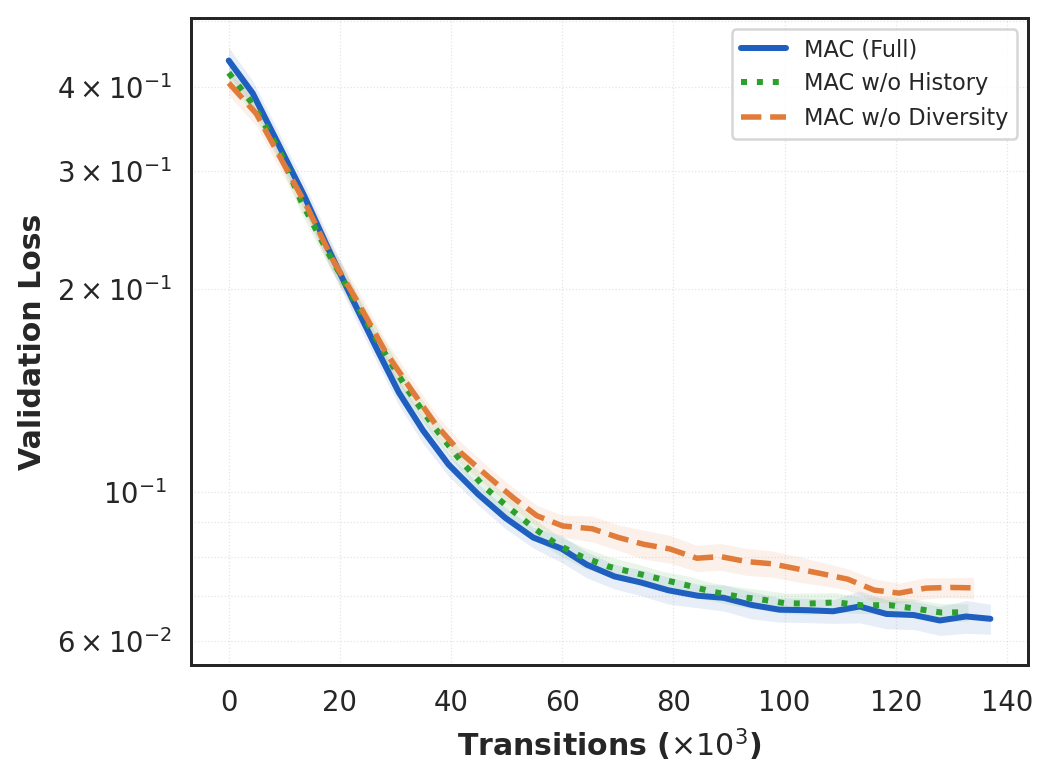

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- compatibility for script / notebook ---
try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.path.join(os.getcwd(), "trainer") if os.path.basename(os.getcwd()) != "trainer" else os.getcwd()

# -----------------------------
# Paths
# -----------------------------
csv_mac_path = os.path.join(SCRIPT_DIR, "logs", "results", "experiment_summary_mask3_mse_weighted.csv")
csv_no_div_path = os.path.join(SCRIPT_DIR, "logs", "results", "experiment_summary_mask3_mse_no_diversity_weighted.csv")
csv_no_his_path = os.path.join(SCRIPT_DIR, "logs", "results", "experiment_summary_mask3_mse_no_history_weighted.csv")

# -----------------------------
# Helper
# -----------------------------
def _aggregate_seed_curves_by_iter(
    df,
    y_col,
    seed_col="Seed",
    iter_col="Iter",
    step_col="New_Data_Size",
    warmup_iter=10,
    x_scale=1000,
):
    if df is None or len(df) == 0:
        return None

    df = df.copy()
    needed = [seed_col, iter_col, y_col]
    if step_col in df.columns:
        needed.append(step_col)

    df = df[needed].copy()
    df = df.drop_duplicates(subset=[seed_col, iter_col], keep="last")

    df[iter_col] = pd.to_numeric(df[iter_col], errors="coerce")
    df[y_col] = pd.to_numeric(df[y_col], errors="coerce")

    if step_col in df.columns:
        df[step_col] = pd.to_numeric(df[step_col], errors="coerce")

    df = df[df[iter_col] > warmup_iter].copy()
    df = df[np.isfinite(df[iter_col]) & np.isfinite(df[y_col])]

    if len(df) == 0:
        return None

    grouped = df.groupby(iter_col)

    out = grouped[y_col].agg(["mean", "std"]).reset_index()
    out = out.rename(columns={"mean": y_col, "std": f"{y_col}_std"})

    if step_col in df.columns:
        step_mean = grouped[step_col].mean().reset_index(name="step_mean")
        out = out.merge(step_mean, on=iter_col, how="left")
        out["x_raw"] = out["step_mean"].fillna(0).cumsum()
    else:
        out["x_raw"] = out[iter_col]

    out["x_raw"] = out["x_raw"] - out["x_raw"].iloc[0]
    out["x_k"] = out["x_raw"] / x_scale
    return out

# -----------------------------
# Plot: single MSE figure
# -----------------------------
def run_ablation_plot():
    mse_col = "WM_Val_Loss"
    warmup = 10

    datasets = {}
    for name, path in [
        ("MAC", csv_mac_path),
        ("no_history", csv_no_his_path),
        ("no_diversity", csv_no_div_path),
    ]:
        if os.path.exists(path):
            df_raw = pd.read_csv(path)
            datasets[name] = _aggregate_seed_curves_by_iter(
                df_raw,
                y_col=mse_col,
                warmup_iter=warmup,
                step_col="New_Data_Size",
                x_scale=1000,
            )
        else:
            print(f"[Warning] File not found: {path}")
            datasets[name] = None

    styles = {
        "MAC": {
            "color": "#1F5FBF",
            "ls": "-",
            "label": "MAC (Full)",
            "lw": 2.4,
        },
        "no_history": {
            "color": "#2CA02C",
            "ls": ":",
            "label": "MAC w/o History",
            "lw": 2.4,
        },
        "no_diversity": {
            "color": "#E07B39",
            "ls": "--",
            "label": "MAC w/o Diversity",
            "lw": 2.2,
        },
    }

    fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))

    alpha_ema = 0.25

    for name in ["MAC", "no_history", "no_diversity"]:
        d = datasets.get(name)
        if d is None or mse_col not in d.columns:
            continue

        s = styles[name]
        x = d["x_k"].to_numpy()
        y = d[mse_col].to_numpy()
        ystd = d.get(f"{mse_col}_std", pd.Series(np.zeros(len(d)))).fillna(0).to_numpy()

        mask = np.isfinite(x) & np.isfinite(y) & (y > 0)
        x = x[mask]
        y = y[mask]
        ystd = ystd[mask]

        if len(x) == 0:
            continue

        y_smooth = pd.Series(y).ewm(alpha=alpha_ema, adjust=False).mean().to_numpy()
        ystd_s = pd.Series(ystd).ewm(alpha=alpha_ema, adjust=False).mean().to_numpy()

        ax.plot(
            x,
            y_smooth,
            color=s["color"],
            ls=s["ls"],
            label=s["label"],
            linewidth=s["lw"],
        )

        ax.fill_between(
            x,
            np.maximum(y_smooth - ystd_s * 0.35, 1e-8),
            y_smooth + ystd_s * 0.35,
            color=s["color"],
            alpha=0.10,
            lw=0,
        )

    ax.set_xlabel(r"Transitions ($\times 10^3$)", fontweight="bold")
    ax.set_ylabel("Validation Loss", fontweight="bold")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle=":", alpha=0.5, linewidth=0.5)
    ax.legend(frameon=True, edgecolor="0.8", fontsize=9)

    plt.tight_layout()
    plt.savefig("ablation_minigrid_mse.png", dpi=300, bbox_inches="tight")
    plt.show()

if __name__ == "__main__":
    run_ablation_plot()


UED VS baseline VS DR


In [13]:
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==========================================================
# 保持你原来的格式
# ==========================================================

sns.set_theme(style="whitegrid", font="serif")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "serif"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": (12, 10),
    "lines.linewidth": 2.5,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# ==========================================================
# 自动识别 seed 列
# ==========================================================

def get_seed_column(df):
    if "Seed" in df.columns:
        return "Seed"
    if "seed" in df.columns:
        return "seed"
    df["Seed"] = 0
    return "Seed"

# ==========================================================
# 插值 + seed mean/std
# ==========================================================

def compute_seed_mean_std_interpolated(df, loss_col, seed_col, grid_points=200):

    seeds = df[seed_col].unique()

    mins, maxs = [], []
    for s in seeds:
        d = df[df[seed_col] == s]
        mins.append(d["Transitions"].min())
        maxs.append(d["Transitions"].max())

    global_min = max(mins)
    global_max = min(maxs)

    grid = np.linspace(global_min, global_max, grid_points)

    all_curves = []

    for s in seeds:
        d = df[df[seed_col] == s]
        x = d["Transitions"].values
        y = d[loss_col].values
        interp_y = np.interp(grid, x, y)
        all_curves.append(interp_y)

    all_curves = np.array(all_curves)

    mean = np.mean(all_curves, axis=0)
    std = np.std(all_curves, axis=0)

    return grid, mean, std

# ==========================================================
# 主函数
# ==========================================================

def plot_three_methods_warmup_aligned(
    ued_path,
    dr_path,
    baseline_path,
    warmup_iter=10,
    max_k=150  # 横轴最大值（k transitions）
):

    max_transition = max_k * 1000

    methods = {
        "MAC": {
            "path": ued_path,
            "color": "#1f77b4",
            "style": "-"
        },
        "DR Baseline": {
            "path": dr_path,
            "color": "#d62728",
            "style": "--"
        },
        "Baseline": {
            "path": baseline_path,
            "color": "#2ca02c",
            "style": "-."
        }
    }

    fig, ax = plt.subplots(figsize=(8, 6))

    for label, config in methods.items():

        p = config["path"]
        if not os.path.exists(p) and os.path.exists("trainer/" + p):
            p = "trainer/" + p

        if not os.path.exists(p):
            print(f"[Warning] Missing: {p}")
            continue

        df = pd.read_csv(p)
        seed_col = get_seed_column(df)

        # =========================================
        # Baseline
        # =========================================
        if "transitions" in df.columns:

            loss_col = "avg_target_loss"
            df["Transitions"] = df["transitions"]

        # =========================================
        # UED / DR
        # =========================================
        else:

            loss_col = "WM_Val_Loss"
            df = df.sort_values([seed_col, "Iter"])

            if label == "MAC":
                # 只对 MAC 过滤 warmup
                df = df[df["Iter"] > warmup_iter].copy()

            df["Transitions"] = df.groupby(seed_col)["New_Data_Size"].cumsum()

        # =========================================
        # 限制最大 transition（统计也裁剪）
        # =========================================
        df = df[df["Transitions"] <= max_transition].copy()

        if len(df) == 0:
            continue

        # =========================================
        # 计算 mean/std
        # =========================================

        grid, mean, std = compute_seed_mean_std_interpolated(
            df,
            loss_col,
            seed_col
        )

        x = grid / 1000  # k transitions

        ax.plot(
            x,
            mean,
            label=label,
            color=config["color"],
            linestyle=config["style"],
            linewidth=2.5
        )

        ax.fill_between(
            x,
            mean - std,
            mean + std,
            color=config["color"],
            alpha=0.15
        )

    ax.set_title("Generalization Performance Comparison", fontweight='bold')
    ax.set_xlabel(r"Transitions ($\times 10^3$)")
    ax.set_ylabel("Target Task Loss (Log Scale)")
    ax.set_yscale("log")
    ax.set_xlim(0, max_k)  # 限制横轴显示
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend()

    save_path = "three_method_comparison.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved to {save_path}")

# ==========================================================
# main
# ==========================================================

if __name__ == "__main__":

    f_ued = "logs/results/experiment_summary_mask3_mse_weighted.csv"
    f_dr = "logs/results_dr/experiment_summary_dr_mask_3_mse_weighted.csv"
    f_baseline = "logs/results/target_loss_baseline_ued.csv"

    plot_three_methods_warmup_aligned(
        f_ued,
        f_dr,
        f_baseline,
        warmup_iter=10,
        max_k=150
    )


[Warning] Missing: logs/results_dr/experiment_summary_dr_mask_3_mse_weighted.csv
[Warning] Missing: logs/results/target_loss_baseline_ued.csv
Saved to three_method_comparison.png


### visualization for Crafter

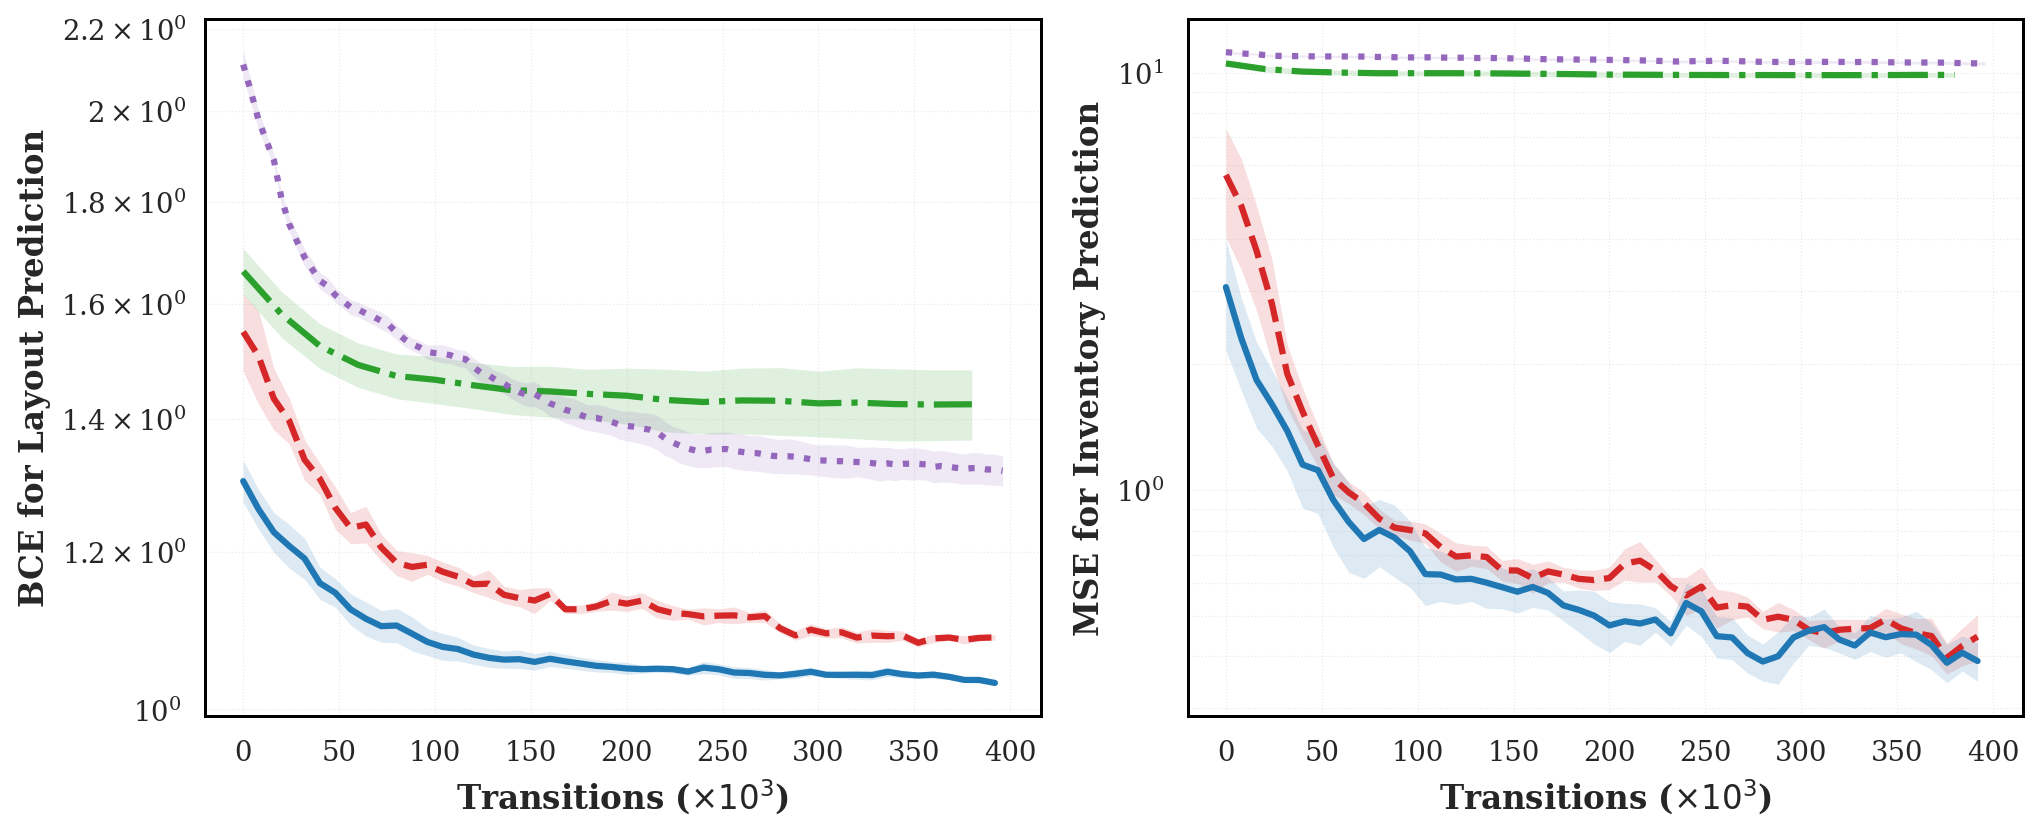

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# -----------------------------
# 1. 样式配置
# -----------------------------
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "axes.linewidth": 1.2,
    "figure.dpi": 180,
})

# -----------------------------
# 2. 路径配置 (真实的 Crafter 实验路径)
# -----------------------------
csv_ued_path = './logs/results/crafter_ued_results_mask5.csv'
csv_dr_path = './logs/results_dr/dr_summary_crafter_mask5.csv'
csv_baseline_path = './logs/results_target_baseline/crafter_baseline_results.csv'
csv_p2e_path = './logs/p2e_baseline_crafter_n4000_m5_summary.csv'

def _load_dr_dataframe():
    if not os.path.exists(csv_dr_path):
        return None
    return pd.read_csv(csv_dr_path)

# -----------------------------
# 3. 核心聚合函数 (包含完整的异常防护)
# -----------------------------
def _aggregate_seed_curves(
    df,
    y_cols,
    seed_col='Seed',
    iter_col='Iter',
    warmup_iter=0,
    step_col=None,
    cumulative_col=None,
    x_scale=1000,
    reset_from_first=False
):
    if df is None or len(df) == 0:
        return None

    df = df.copy()
    needed = [seed_col, iter_col] + [c for c in y_cols if c in df.columns]
    if step_col and step_col in df.columns:
        needed.append(step_col)
    if cumulative_col and cumulative_col in df.columns:
        needed.append(cumulative_col)

    needed = list(dict.fromkeys(needed))
    df = df[needed].copy()
    df = df.sort_values([seed_col, iter_col])

    per_seed = []
    for seed, g in df.groupby(seed_col):
        g = g.sort_values(iter_col).copy()

        if cumulative_col and cumulative_col in g.columns:
            g['x_raw'] = pd.to_numeric(g[cumulative_col], errors='coerce')
        elif step_col and step_col in g.columns:
            g['x_raw'] = pd.to_numeric(g[step_col], errors='coerce').cumsum()
        else:
            g['x_raw'] = pd.to_numeric(g[iter_col], errors='coerce')

        if warmup_iter > 0:
            g = g[pd.to_numeric(g[iter_col], errors='coerce') > warmup_iter].copy()
            if len(g) == 0:
                continue

        if reset_from_first and len(g) > 0:
            g['x_raw'] = g['x_raw'] - g['x_raw'].iloc[0]

        g['x_k'] = g['x_raw'] / x_scale
        g[seed_col] = seed
        per_seed.append(g)

    if len(per_seed) == 0:
        return None

    merged = pd.concat(per_seed, axis=0, ignore_index=True)

    valid_cols = [c for c in y_cols if c in merged.columns]
    if not valid_cols:
        print(f"  [Warning] 没有找到任何匹配的指标: {y_cols}")
        return None

    for c in valid_cols:
        merged[c] = pd.to_numeric(merged[c], errors='coerce')

    agg_dict = {c: ['mean', 'std'] for c in valid_cols}
    out = merged.groupby('x_k', as_index=False).agg(agg_dict)

    out.columns = [
        col[0] if col[1] == '' else (col[0] if col[1] == 'mean' else f'{col[0]}_{col[1]}')
        for col in out.columns.to_flat_index()
    ]
    return out

# -----------------------------
# 4. 执行绘图 (1x2 布局，起点对齐，无图例)
# -----------------------------
def run_publication_visualization_final():
    metric_cols = ['target_val_val_ce_loss', 'target_val_val_inv_loss']
    
    # 强制所有方法都加上 reset_from_first=True，保证 x 轴从 0 左右共同出发
    df_base = None
    if os.path.exists(csv_baseline_path):
        df_base_raw = pd.read_csv(csv_baseline_path)
        iter_c = 'Phase' if 'Phase' in df_base_raw.columns else 'Iter'
        df_base = _aggregate_seed_curves(df_base_raw, metric_cols, iter_col=iter_c, 
                                         step_col='data_size' if 'data_size' in df_base_raw.columns else None, 
                                         cumulative_col='cumulative_data_size' if 'cumulative_data_size' in df_base_raw.columns else None,
                                         reset_from_first=True)
        
    df_dr = _aggregate_seed_curves(_load_dr_dataframe(), metric_cols, step_col='New_Data_Size', reset_from_first=True)
    
    df_ued = None
    if os.path.exists(csv_ued_path):
        df_ued = _aggregate_seed_curves(pd.read_csv(csv_ued_path), metric_cols, warmup_iter=10, step_col='New_Data_Size', reset_from_first=True)
        
    df_p2e = None
    if os.path.exists(csv_p2e_path):
        df_p2e = _aggregate_seed_curves(pd.read_csv(csv_p2e_path), metric_cols, cumulative_col='Cumulative_Transitions', reset_from_first=True)

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
    
    styles = {
        'DR':       {'df': df_dr,   'color': '#d62728', 'ls': '--', 'label': 'DR'},
        'UED':      {'df': df_ued,  'color': '#1f77b4', 'ls': '-',  'label': 'MAC (Ours)'},
        'Baseline': {'df': df_base, 'color': '#2ca02c', 'ls': '-.', 'label': 'Target Baseline'},
        'P2E':      {'df': df_p2e,  'color': '#9467bd', 'ls': ':',  'label': 'P2E'},
    }

    panels = [
        ("target_val_val_ce_loss", "BCE for Layout Prediction"),
        ("target_val_val_inv_loss", "MSE for Inventory Prediction"),
    ]

    alpha_ema = 0.6    # 保留高频毛刺细节
    std_scale = 0.45   # 收窄阴影防止过度重叠

    for i, (col, ylabel) in enumerate(panels):
        ax = axes[i]
        
        for side in ['top', 'right', 'bottom', 'left']:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_color('black')

        for name in ['DR', 'UED', 'Baseline', 'P2E']:
            s = styles[name]
            d = s['df']
            if d is None or col not in d.columns: continue

            x = d['x_k'].values
            y_raw = d[col].values
            
            mask = np.isfinite(x) & np.isfinite(y_raw)
            if mask.sum() == 0: continue
                
            x_m = x[mask]
            y_m = y_raw[mask]
            
            y_smooth = pd.Series(y_m).ewm(alpha=alpha_ema, adjust=False).mean().values
            
            # 绘图主体
            ax.plot(x_m, y_smooth, color=s['color'], ls=s['ls'], label=s['label'], lw=2.5, zorder=10)

            std_col = col + '_std'
            if std_col in d.columns:
                std_m = d[std_col].fillna(0).values[mask]
                std_smooth = pd.Series(std_m).ewm(alpha=alpha_ema, adjust=False).mean().values
                ax.fill_between(x_m, y_smooth - std_smooth*std_scale, y_smooth + std_smooth*std_scale, 
                                color=s['color'], alpha=0.15, lw=0)

        # 轴标签及格式
        ax.set_ylabel(ylabel, fontweight='bold', fontsize=13)
        ax.set_xlabel(r"Transitions ($\times 10^3$)", fontweight='bold', fontsize=13)
        ax.set_yscale('log')
        import matplotlib.ticker as ticker
        ax.yaxis.set_major_locator(ticker.LogLocator(numticks=6))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}"))
        ax.yaxis.set_minor_formatter(ticker.NullFormatter())
        ax.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.4)

    plt.tight_layout()
    plt.show()

run_publication_visualization_final()


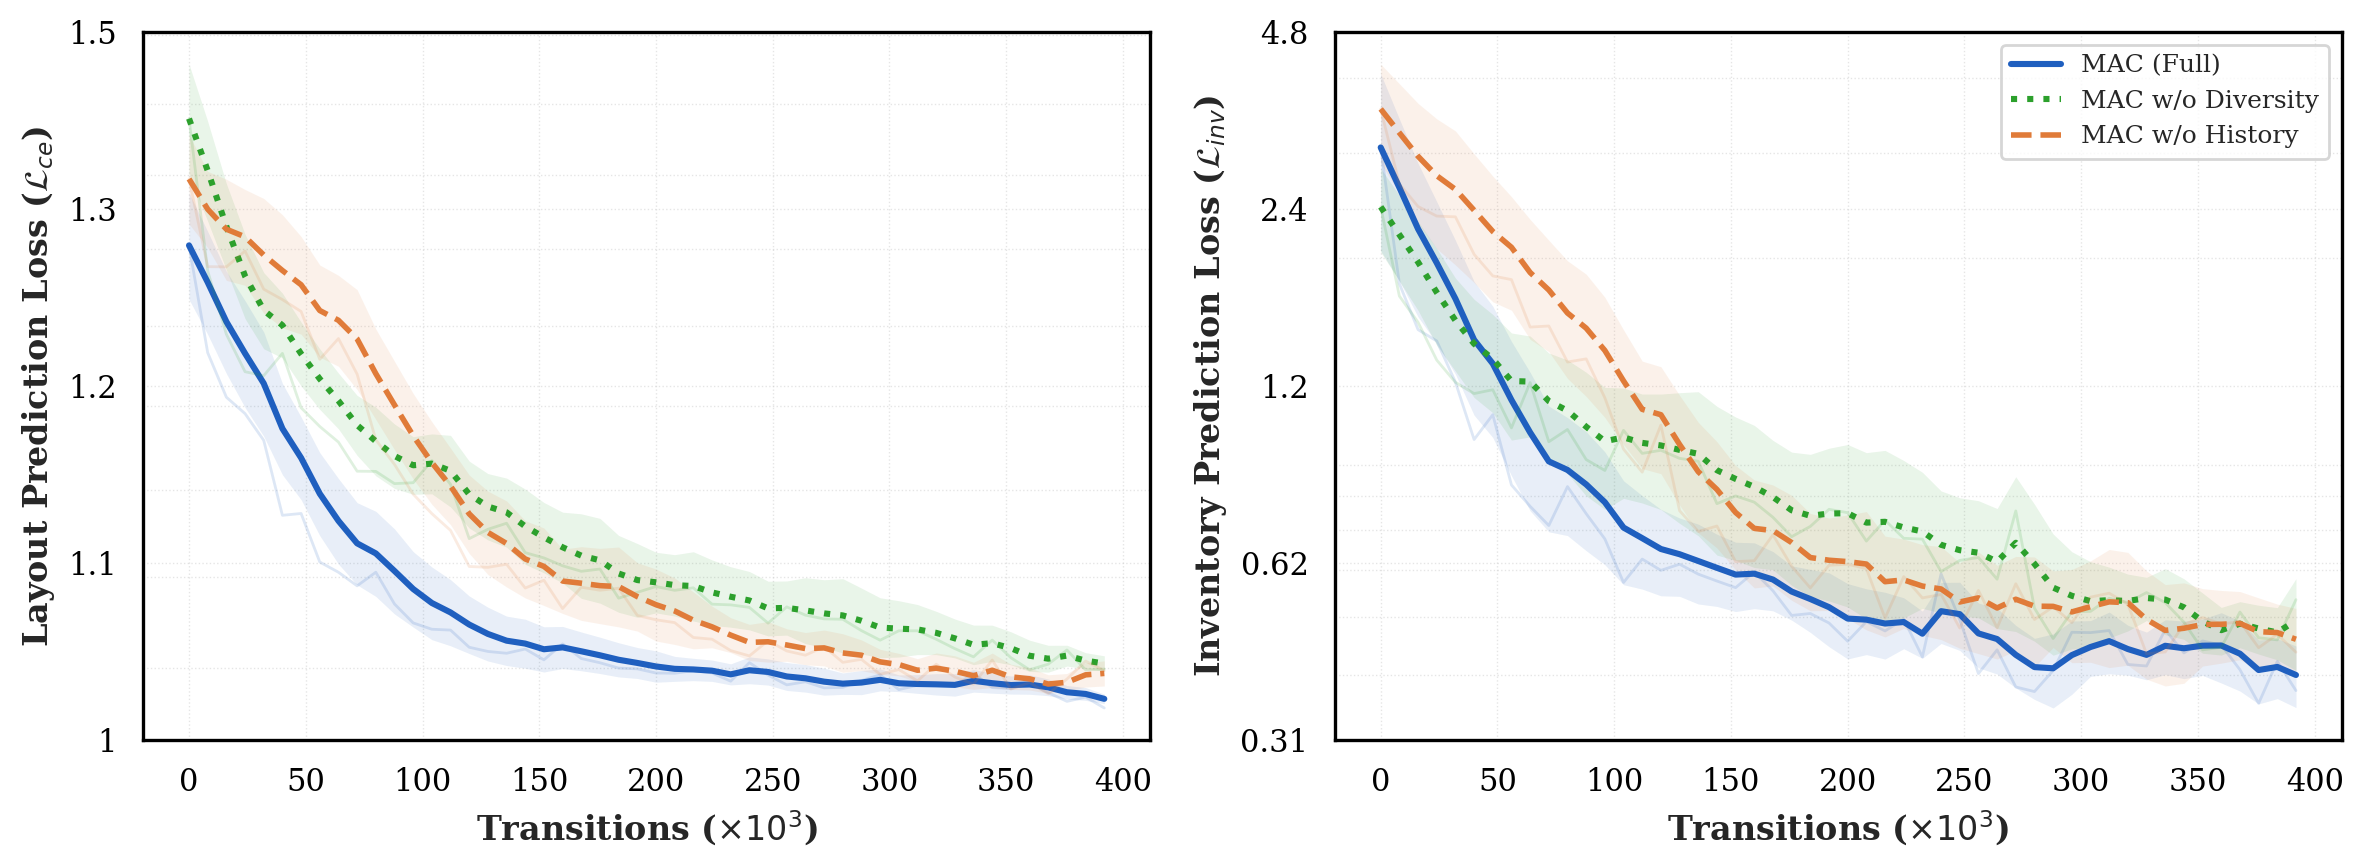

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 兼容性处理 ---
try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer'

# -----------------------------
# Paths
# -----------------------------
# 路径名根据你的文件习惯做了微调，确保能读到数据
csv_mac_path = os.path.join(SCRIPT_DIR, 'logs', 'results', 'crafter_ued_results_mask5.csv')
csv_no_his_path = os.path.join(SCRIPT_DIR, 'logs', 'results', 'crafter_ued_results_mask5_no_history.csv')
csv_no_div_path = os.path.join(SCRIPT_DIR, 'logs', 'results', 'crafter_ued_results_mask5_no_diversity.csv')

# -----------------------------
# Helper (聚合逻辑)
# -----------------------------
def _aggregate_seed_curves(df, y_cols, seed_col='Seed', iter_col='Iter', warmup_iter=0, step_col=None, x_scale=1000, recompute_after_warmup=False):
    if df is None or len(df) == 0: return None
    df = df.copy()
    needed = [seed_col, iter_col] + [c for c in y_cols if c in df.columns]
    if step_col and step_col in df.columns: needed.append(step_col)
    df = df[needed].copy()
    per_seed = []
    for seed, g in df.groupby(seed_col):
        g = g.sort_values(iter_col).copy()
        if warmup_iter > 0:
            g = g[pd.to_numeric(g[iter_col], errors='coerce') > warmup_iter].copy()
            if len(g) == 0: continue
        if recompute_after_warmup and step_col and step_col in g.columns:
            g['x_raw'] = pd.to_numeric(g[step_col], errors='coerce').cumsum()
        elif step_col and step_col in g.columns:
            g['x_raw'] = pd.to_numeric(g[step_col], errors='coerce').cumsum()
        else:
            g['x_raw'] = pd.to_numeric(g[iter_col], errors='coerce')
        g['x_raw'] = g['x_raw'] - g['x_raw'].iloc[0]
        g['x_k'] = g['x_raw'] / x_scale
        per_seed.append(g)
    if not per_seed: return None
    merged = pd.concat(per_seed, axis=0, ignore_index=True)
    valid_y_cols = [c for c in y_cols if c in merged.columns]
    agg_dict = {c: ['mean', 'std'] for c in valid_y_cols}
    out = merged.groupby('x_k', as_index=False).agg(agg_dict)
    out.columns = [col[0] if col[1] == '' else (col[0] if col[1] == 'mean' else f'{col[0]}_{col[1]}') for col in out.columns.to_flat_index()]
    return out

# -----------------------------
# Plot: 1x2 (Left CE, Right MSE)
# -----------------------------
def run_ablation_plot():
    ce_col = 'target_val_val_ce_loss'    # Layout Loss (CE)
    inv_col = 'target_val_val_inv_loss'  # Inventory Loss (MSE)
    y_cols = [ce_col, inv_col]
    warmup = 10 

    datasets = {}
    for name, path in [('MAC', csv_mac_path), ('no_history', csv_no_his_path), ('no_diversity', csv_no_div_path)]:
        if os.path.exists(path):
            df_raw = pd.read_csv(path).drop_duplicates(subset=['Seed', 'Iter'], keep='last')
            datasets[name] = _aggregate_seed_curves(df_raw, y_cols=y_cols, warmup_iter=warmup, step_col='New_Data_Size', recompute_after_warmup=True)
        else:
            datasets[name] = None

    # --- 样式：MAC 设为绿色 ---
    styles = {
        'MAC':          {'color': '#1F5FBF', 'ls': '-',  'label': 'MAC (Full)',          'lw': 2.2},
        'no_diversity': {'color': '#E07B39', 'ls': '--', 'label': 'MAC w/o History',     'lw': 2.0},
        'no_history':   {'color': '#2CA02C', 'ls': ':',  'label': 'MAC w/o Diversity',   'lw': 2.2},
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    plot_configs = [
        (ce_col, r'Layout Prediction Loss ($\mathcal{L}_{ce}$)'),      # 第一个图：CE
        (inv_col, r'Inventory Prediction Loss ($\mathcal{L}_{inv}$)'), # 第二个图：MSE
    ]

    for ax_idx, (col, ylabel) in enumerate(plot_configs):
        ax = axes[ax_idx]
        
        for side in ['top', 'right', 'bottom', 'left']:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_color('black')
            ax.spines[side].set_linewidth(1.2)

        for name in ['MAC', 'no_history', 'no_diversity']:
            d = datasets.get(name)
            if d is None or col not in d.columns: continue
            s = styles[name]
            x, y = d['x_k'].values, d[col].values
            mask = np.isfinite(x) & np.isfinite(y) & (y > 0)
            
            alpha_ema = 0.35
            y_smooth = pd.Series(y[mask]).ewm(alpha=alpha_ema, adjust=False).mean().to_numpy()

            ax.plot(x[mask], y[mask], color=s['color'], alpha=0.15, linewidth=1.0)
            ax.plot(x[mask], y_smooth, color=s['color'], ls=s['ls'], label=s['label'], linewidth=s['lw'])

            std_col = col + '_std'
            if std_col in d.columns:
                ystd = d[std_col].fillna(0).values[mask]
                ystd_s = pd.Series(ystd).ewm(alpha=alpha_ema, adjust=False).mean().values
                ax.fill_between(x[mask], y_smooth - ystd_s*0.5, y_smooth + ystd_s*0.5, color=s['color'], alpha=0.1, lw=0)

        ax.set_xlabel(r'Transitions ($\times 10^3$)', fontweight='bold')
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.tick_params(axis='both', colors='black', width=1.0)
        ax.grid(True, which='both', linestyle=':', alpha=0.5, linewidth=0.5)
        
        if ax_idx != 0:
            ax.legend(frameon=True, edgecolor='0.8', fontsize=9)
            
        ax.set_yscale('log')
        import matplotlib.ticker as ticker
        
        # ====== 强制生成 5 个均分的对数刻度，解决空白无数字的问题 ======
        ymin, ymax = ax.get_ylim()
        if ymin < ymax:
            ticks = np.logspace(np.log10(ymin), np.log10(ymax), num=5)
            ax.set_yticks(ticks)
        
        # 强制将刻度数字限制为最多 2 位有效数字，保证短小精悍
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:.2g}"))
        ax.yaxis.set_minor_formatter(ticker.NullFormatter())
        # =========================================================

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_ablation_plot()


### crafter continues learning vs baseline

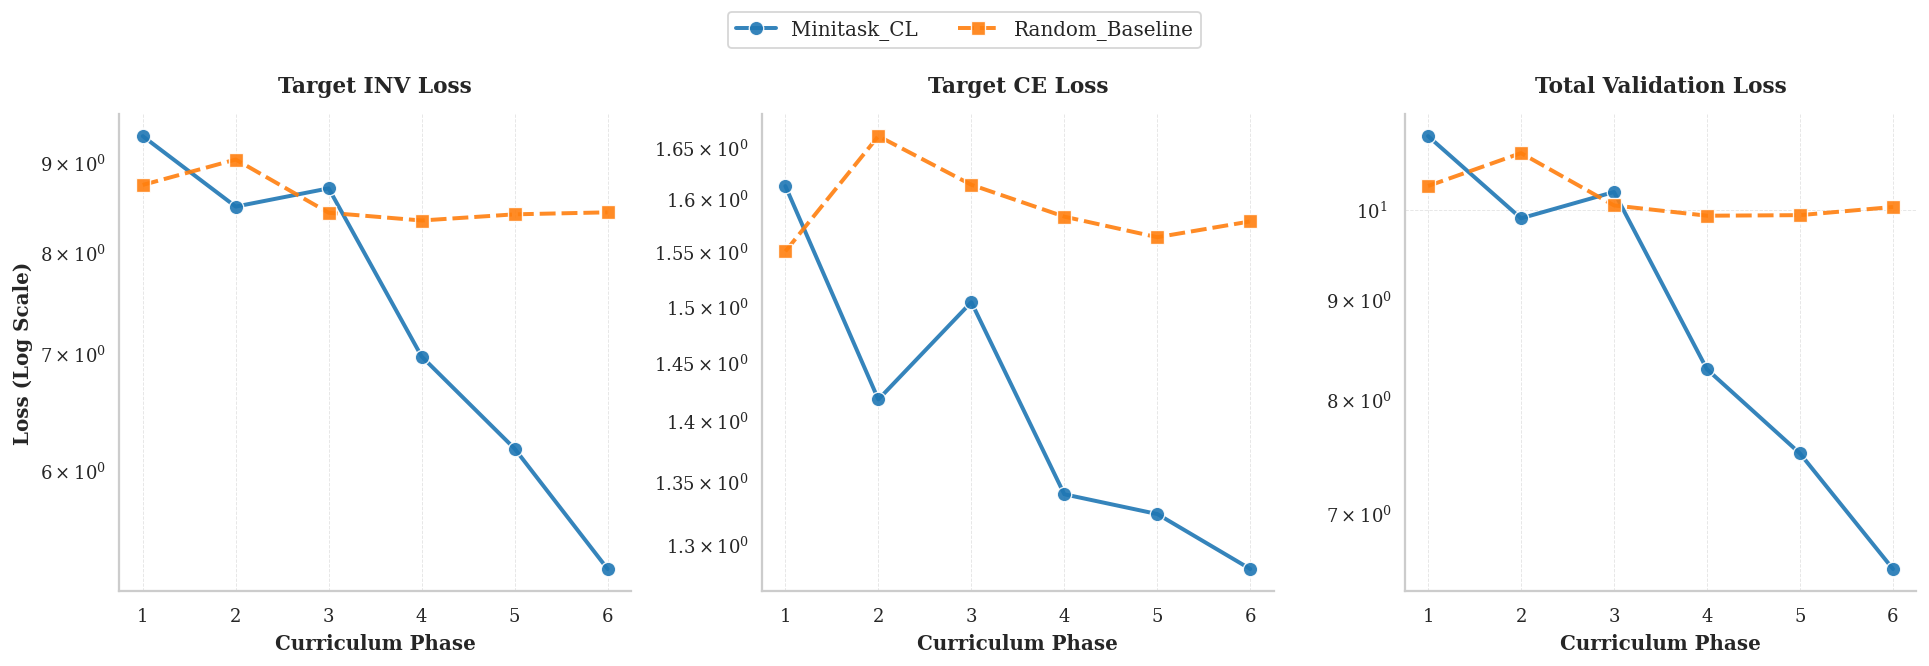

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 确保在 Jupyter 中内联显示
%matplotlib inline

# ----------------- NeurIPS Academic Figure Style -----------------
sns.set_theme(style="whitegrid", font="serif") 
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "serif"],
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 130,
    "savefig.bbox": "tight"
})

# ----------------- 路径设置 -----------------
csv_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/cl_comparison_results.csv'

def plot_cl_comparison():
    # 1. 检查并读取 CSV
    if not os.path.exists(csv_path):
        print(f"Error: 找不到文件 {csv_path}")
        return
    
    df = pd.read_csv(csv_path)

    # 2. 绘图配置 (指标列名, 标题)
    metrics = [
        ('target_val_val_inv_loss', 'Target INV Loss'),
        ('target_val_val_ce_loss', 'Target CE Loss'),
        ('target_val_avg_val_loss_wm', 'Total Validation Loss')
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
    
    # 颜色与标记 (Minitask 用沉稳蓝, Random 用学术橙)
    palette = {'Minitask_CL': '#1F77B4', 'Random_Baseline': '#FF7F0E'}
    markers = {'Minitask_CL': 'o', 'Random_Baseline': 's'}

    for i, (col, title) in enumerate(metrics):
        ax = axes[i]
        
        # 3. 绘制折线图
        sns.lineplot(data=df, x='phase', y=col, hue='experiment_type', 
                     style='experiment_type', markers=markers, palette=palette,
                     linewidth=2.2, markersize=8, ax=ax, alpha=0.9)
        
        # 4. 精细化美化
        ax.set_title(title, fontweight='bold', pad=12)
        ax.set_ylabel('Loss (Log Scale)' if i==0 else '', fontweight='bold')
        ax.set_xlabel('Curriculum Phase', fontweight='bold')
        ax.set_xticks([1, 2, 3, 4, 5, 6])
        
        # 采用 Log Scale 观察
        ax.set_yscale('log')
        import matplotlib.ticker as ticker
        ax.yaxis.set_major_locator(ticker.LogLocator(numticks=6))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}"))
        ax.yaxis.set_minor_formatter(ticker.NullFormatter())
        
        # 网格与边框处理
        ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # 移除默认图例，在全局统一添加
        ax.get_legend().remove()

    # 5. 全局图例整合
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), 
               ncol=2, frameon=True, fontsize=11, edgecolor='0.8')

    plt.tight_layout()
    plt.show()

# 执行
plot_cl_comparison()


### Bipedal continue learning

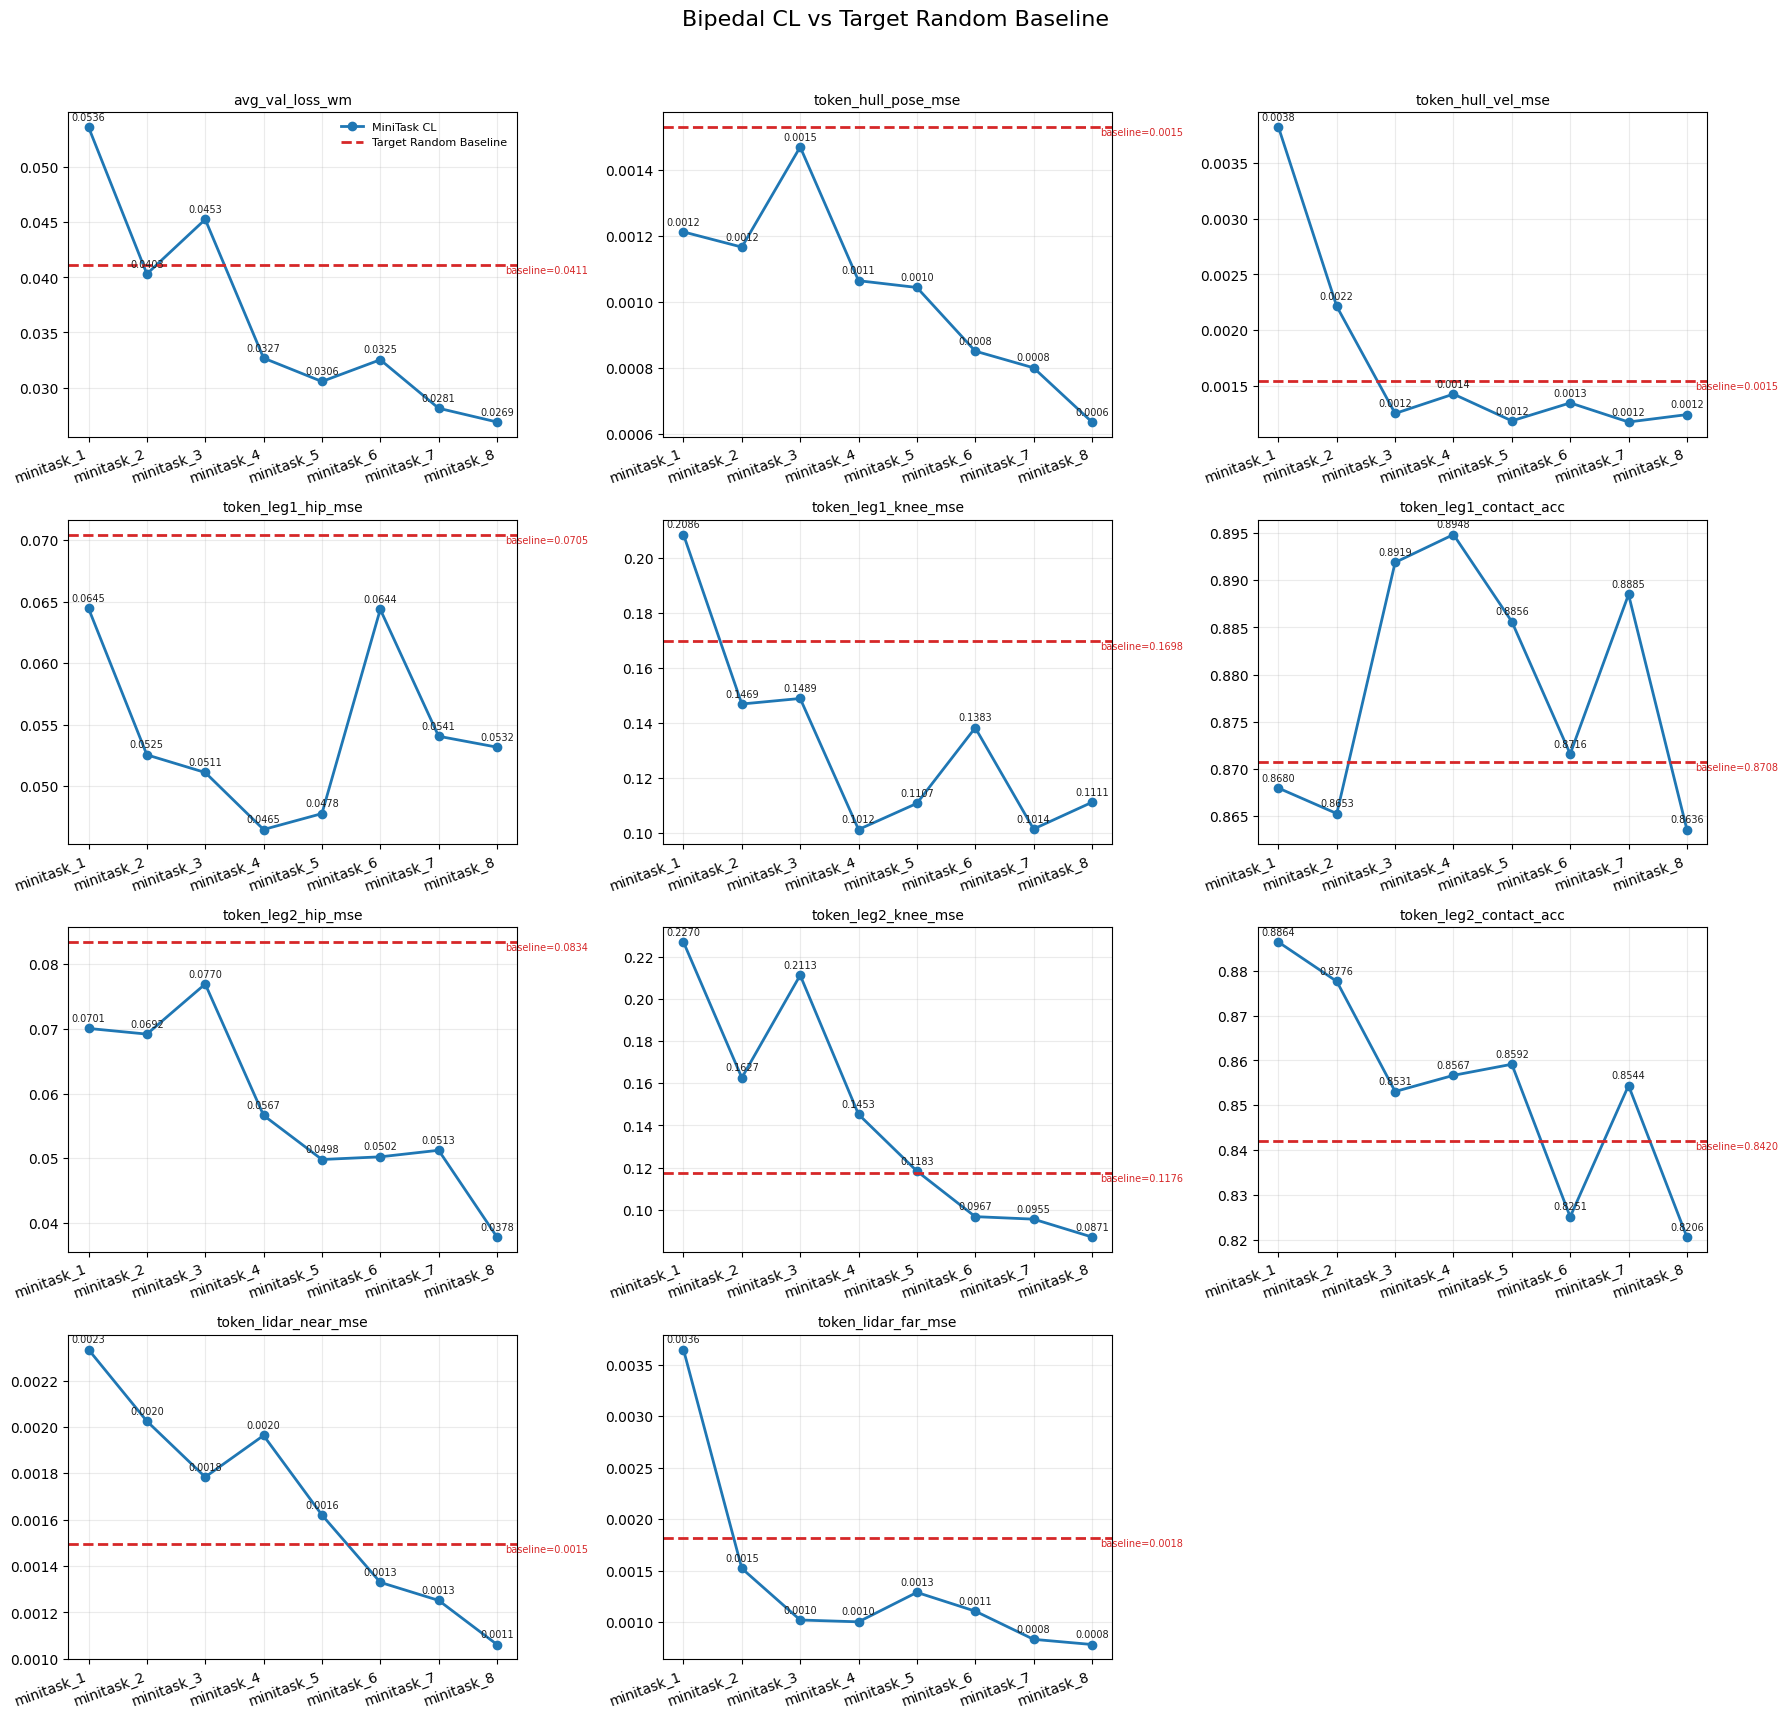

In [4]:
import math
import matplotlib.pyplot as plt
import pandas as pd

csv_path = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/cl_comparison_results.csv"

df = pd.read_csv(csv_path)
df = df[df["domain"] == "bipedalwalker"].copy()

mini_df = (
    df[df["experiment_type"] == "Bipedal_Minitask_CL"]
    .sort_values("phase")
    .reset_index(drop=True)
)

baseline_df = (
    df[df["experiment_type"] == "Bipedal_Target_Random_Baseline"]
    .sort_values("phase")
    .reset_index(drop=True)
)

if mini_df.empty:
    raise ValueError("没有找到 Bipedal_Minitask_CL 的数据")
if baseline_df.empty:
    raise ValueError("没有找到 Bipedal_Target_Random_Baseline 的数据")

baseline_row = baseline_df.iloc[0]

x = list(range(len(mini_df)))
x_labels = mini_df["task"].astype(str).tolist()

non_metric_cols = {"experiment_type", "domain", "phase", "task"}
exclude_metrics = {
    "train_best_val_loss",
    "target_val_token_leg1_contact_bce",
    "target_val_token_leg2_contact_bce",
}

metric_cols = [
    c for c in df.columns
    if c not in non_metric_cols and c not in exclude_metrics
]

if not metric_cols:
    raise ValueError("没有找到可绘制的指标列")

n_metrics = len(metric_cols)
ncols = 3
nrows = math.ceil(n_metrics / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows))
if n_metrics == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, metric in enumerate(metric_cols):
    ax = axes[i]
    y = mini_df[metric].astype(float).tolist()
    baseline_value = float(baseline_row[metric])

    ax.plot(x, y, marker="o", linewidth=2, color="#1f77b4", label="MiniTask CL")
    ax.axhline(
        baseline_value,
        linestyle="--",
        linewidth=2,
        color="#d62728",
        label="Target Random Baseline"
    )

    for xi, yi in zip(x, y):
        ax.annotate(
            f"{yi:.4f}",
            (xi, yi),
            textcoords="offset points",
            xytext=(0, 5),
            ha="center",
            fontsize=7,
            color="#1f1f1f"
        )

    ax.annotate(
        f"baseline={baseline_value:.4f}",
        (x[-1], baseline_value),
        textcoords="offset points",
        xytext=(6, -6),
        ha="left",
        fontsize=7,
        color="#d62728"
    )

    ax.set_title(metric.replace("target_val_", ""), fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=20, ha="right")
    ax.grid(True, alpha=0.25)

    if i == 0:
        ax.legend(fontsize=8, frameon=False, loc="best")

for j in range(n_metrics, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Bipedal CL vs Target Random Baseline", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()


### Bipedal MAC vs all baselines

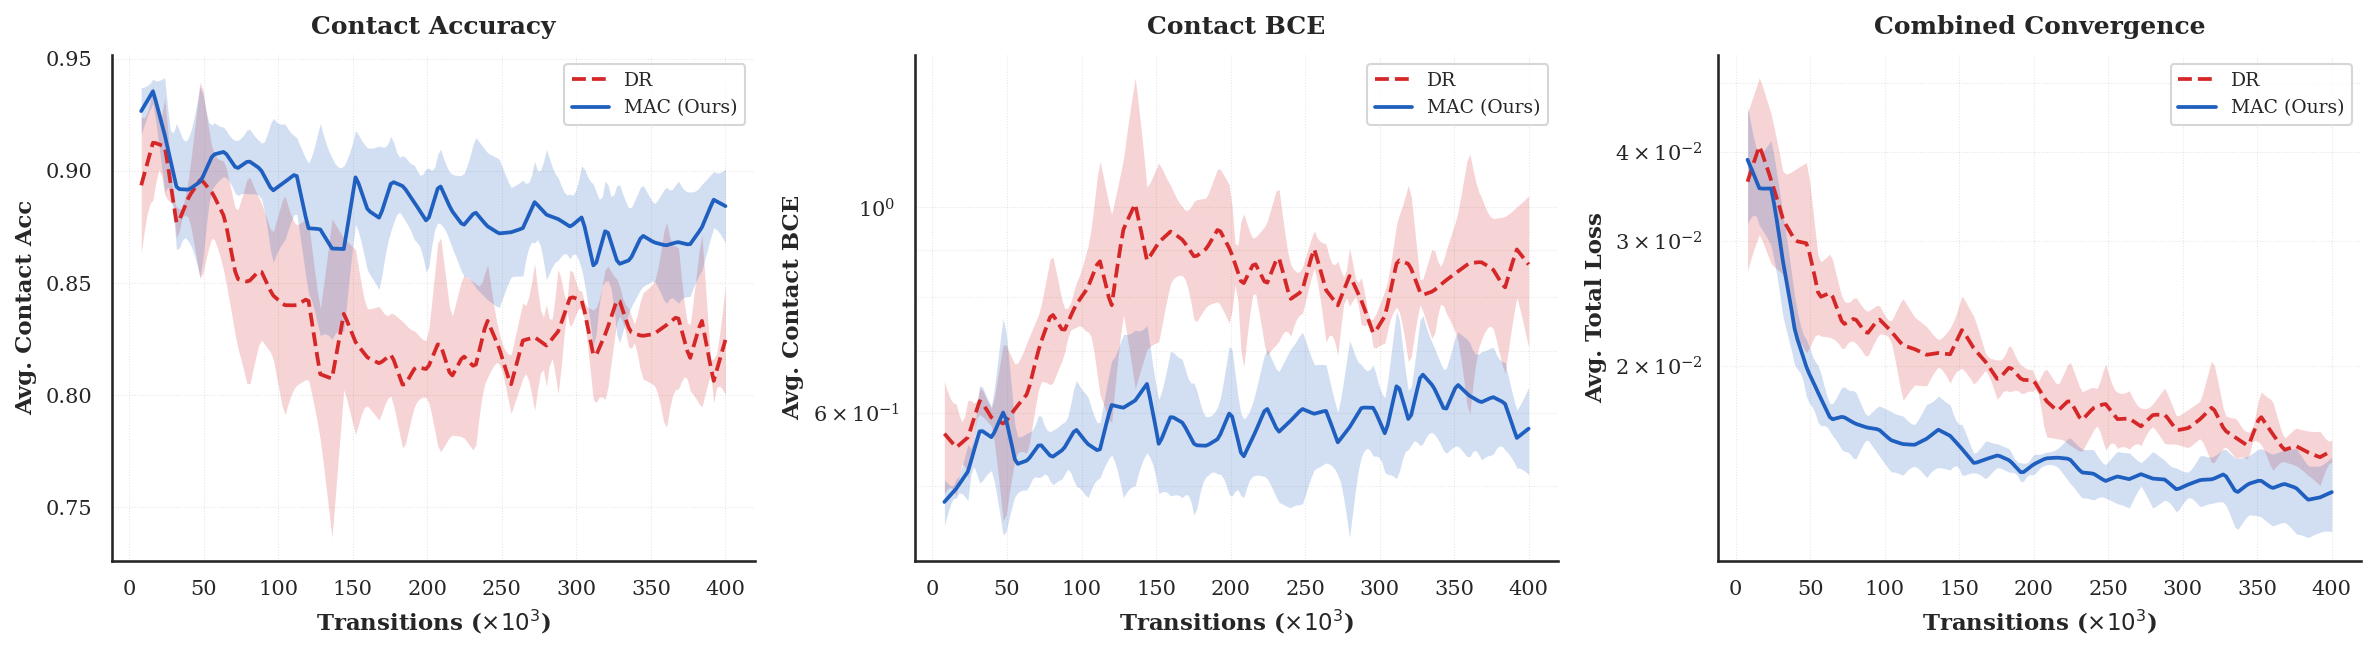

In [5]:
def run_bipedal_visualization():
    needed = [csv_ued_path]
    if not all(os.path.exists(p) for p in needed):
        print("Error: 找不到部分 CSV 文件，请检查路径。")
        return

    metric_cols = ['target_val_contact_acc', 'target_val_contact_bce', 'target_val_avg_val_loss_wm']

    # DR: 从头开始显示，不裁 warmup，保留原生相对坐标
    df_dr_raw = _load_dr_dataframe()
    df_dr_raw = df_dr_raw.drop_duplicates(subset=['Seed', 'Iter'], keep='last')
    df_dr = _aggregate_seed_curves(
        df_dr_raw,
        y_cols=metric_cols,
        seed_col='Seed',
        iter_col='Iter',
        warmup_iter=0,
        step_col='New_Data_Size',
        cumulative_col=None,
        x_scale=1000,
        reset_from_first=False,
    )

    # UED / MAC: 去掉前 10 轮 warmup
    df_ued_raw = pd.read_csv(csv_ued_path)
    df_ued_raw = df_ued_raw.drop_duplicates(subset=['Seed', 'Iter'], keep='last')
    df_ued = _aggregate_seed_curves(
        df_ued_raw,
        y_cols=metric_cols,
        seed_col='Seed',
        iter_col='Iter',
        warmup_iter=10,
        step_col='New_Data_Size',
        cumulative_col=None,
        x_scale=1000,
        reset_from_first=False,  # <===== 修改点在这里：改成 False，关闭首点归零！
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    configs = [
        ('target_val_contact_acc', 'Avg. Contact Acc', 'Contact Accuracy'),
        ('target_val_contact_bce', 'Avg. Contact BCE', 'Contact BCE'),
        ('target_val_avg_val_loss_wm', 'Avg. Total Loss', 'Combined Convergence'),
    ]

    styles = {
        'DR':  {'df': df_dr,  'color': '#D62728', 'ls': '--', 'label': 'DR'},
        'UED': {'df': df_ued, 'color': '#1F5FBF', 'ls': '-',  'label': 'MAC (Ours)'},
    }

    for i, (col, ylabel, title) in enumerate(configs):
        ax = axes[i]

        for name in ['DR', 'UED']:
            s = styles[name]
            d = s['df']
            if col not in d.columns:
                continue

            ax.plot(
                d['x_k'],
                d[col],
                color=s['color'],
                ls=s['ls'],
                label=s['label'],
                linewidth=1.8
            )

            std_col = col + '_std'
            if std_col in d.columns:
                ax.fill_between(
                    d['x_k'],
                    d[col] - d[std_col],
                    d[col] + d[std_col],
                    color=s['color'],
                    alpha=0.20,
                    linewidth=0
                )

        ax.set_title(title, fontweight='bold', pad=10)
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.set_xlabel(r"Transitions ($\times 10^3$)", fontweight='bold')

        if col in ['target_val_contact_bce', 'target_val_avg_val_loss_wm']:
            ax.set_yscale('log')
            import matplotlib.ticker as ticker
            ax.yaxis.set_major_locator(ticker.LogLocator(numticks=6))
            ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}"))
            ax.yaxis.set_minor_formatter(ticker.NullFormatter())

        ax.grid(True, which='both', linestyle=':', alpha=0.5, linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(loc='best', frameon=True, edgecolor='0.8')

    plt.tight_layout()
    plt.show()

run_bipedal_visualization()


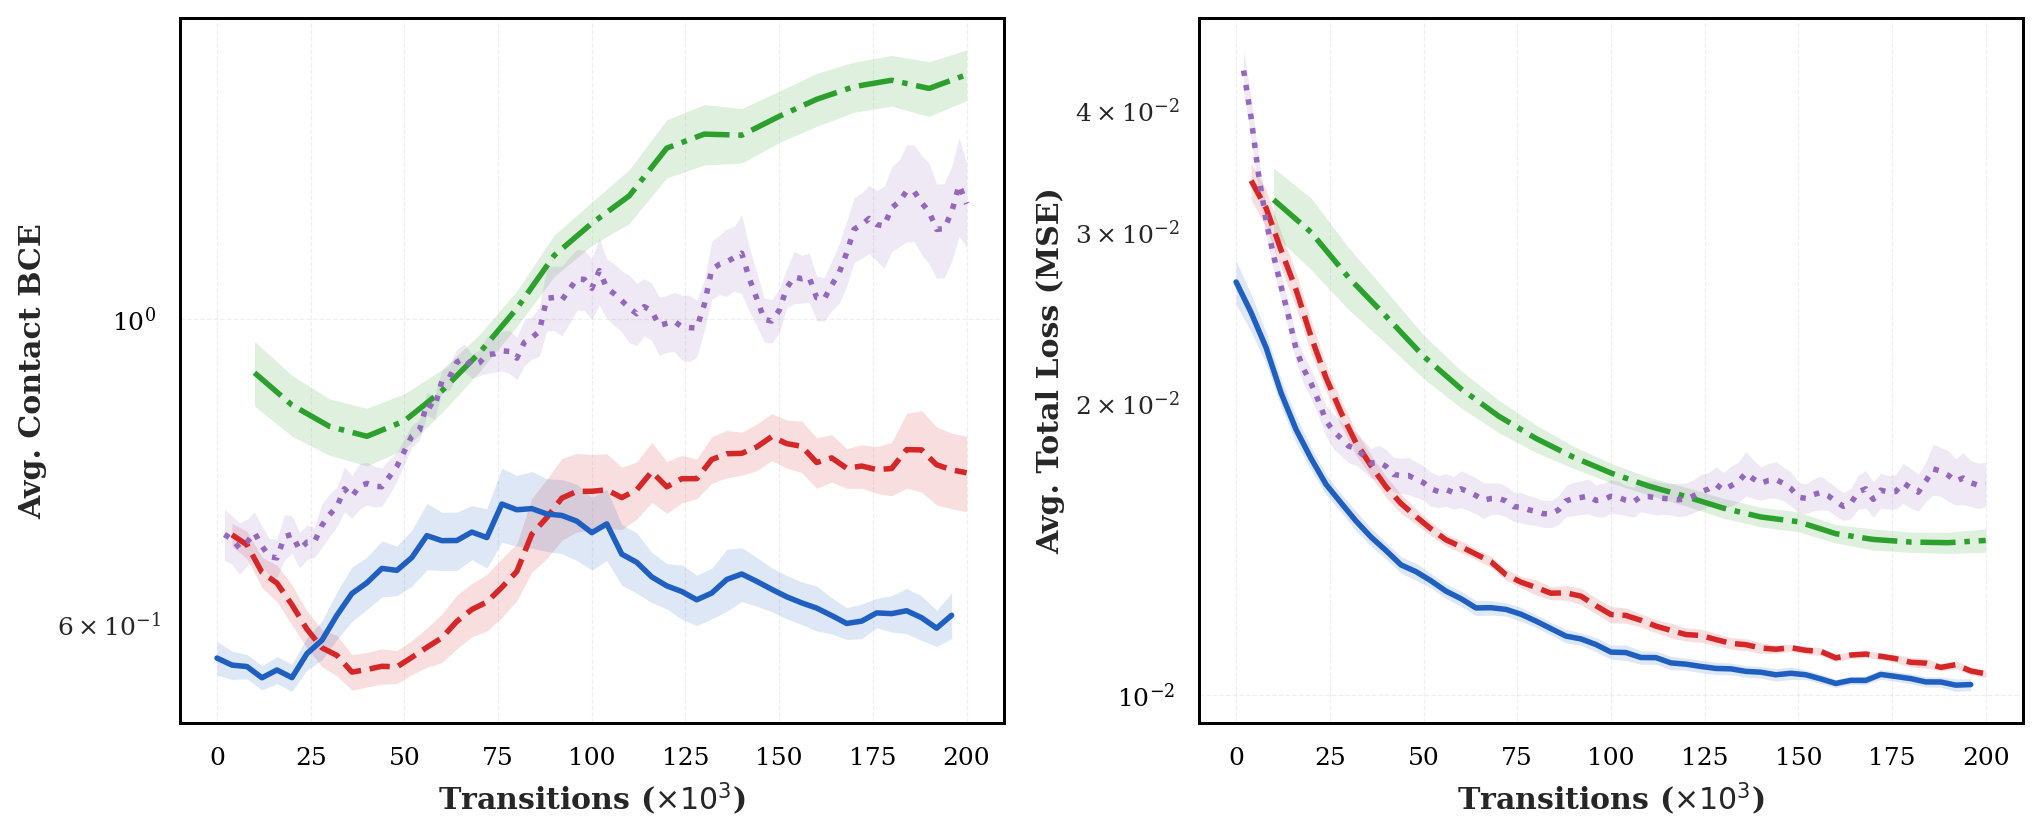

In [8]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# -----------------------------
# Global style: unified with Crafter figure
# -----------------------------
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "axes.linewidth": 0.9,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 180,
    "savefig.bbox": "tight"
})

# -----------------------------
# Paths
# -----------------------------
csv_ued_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/bipedalwalker_ued_results.csv'
csv_dr_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/dr_summary_bipedalwalker.csv'
csv_baseline_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_target_baseline/target_baseline_bipedalwalker.csv'
csv_baseline_mix_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_target_baseline/target_baseline_bipedalwalker_mix.csv'
csv_p2e_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/p2e_baseline_bipedalwalker_n2000_m5_summary.csv'

# -----------------------------
# Helpers
# -----------------------------
def _load_dr_dataframe():
    if not os.path.exists(csv_dr_path):
        print(f"Warning: DR file not found: {csv_dr_path}")
        return None
    return pd.read_csv(csv_dr_path)

def _aggregate_seed_curves(
    df,
    y_cols,
    seed_col='Seed',
    iter_col='Iter',
    warmup_iter=0,
    step_col=None,
    cumulative_col=None,
    x_scale=1000,
    reset_from_first=False
):
    if df is None or len(df) == 0:
        return None

    df = df.copy()
    needed = [seed_col, iter_col] + [c for c in y_cols if c in df.columns]
    if step_col and step_col in df.columns:
        needed.append(step_col)
    if cumulative_col and cumulative_col in df.columns:
        needed.append(cumulative_col)

    df = df[needed].copy()
    df = df.sort_values([seed_col, iter_col])

    per_seed = []
    for seed, g in df.groupby(seed_col):
        g = g.sort_values(iter_col).copy()

        if cumulative_col and cumulative_col in g.columns:
            g['x_raw'] = g[cumulative_col].astype(float)
        elif step_col and step_col in g.columns:
            g['x_raw'] = g[step_col].astype(float).cumsum()
        else:
            g['x_raw'] = g[iter_col].astype(float)

        if warmup_iter > 0:
            g = g[g[iter_col] > warmup_iter].copy()
            if len(g) == 0:
                continue

        if reset_from_first and len(g) > 0:
            g['x_raw'] = g['x_raw'] - g['x_raw'].iloc[0]

        g['x_k'] = g['x_raw'] / x_scale
        g[seed_col] = seed
        per_seed.append(g)

    if len(per_seed) == 0:
        return None

    merged = pd.concat(per_seed, axis=0, ignore_index=True)

    agg_dict = {c: ['mean', 'std'] for c in y_cols if c in merged.columns}
    out = merged.groupby('x_k', as_index=False).agg(agg_dict)

    out.columns = [
        col[0] if col[1] == '' else (col[0] if col[1] == 'mean' else f'{col[0]}_{col[1]}')
        for col in out.columns.to_flat_index()
    ]
    return out

# -----------------------------
# Main Plot
# -----------------------------
def run_bipedal_visualization():
    needed = [csv_ued_path]
    if not all(os.path.exists(p) for p in needed):
        print("Error: 找不到部分 CSV 文件，请检查路径。")
        return

    # 1. 仅保留 BCE 和 Loss 两个指标
    metric_cols = [
        'target_val_contact_bce',
        'target_val_avg_val_loss_wm'
    ]

    # DR
    df_dr = None
    df_dr_raw = _load_dr_dataframe()
    if df_dr_raw is not None:
        df_dr_raw = df_dr_raw.drop_duplicates(subset=['Seed', 'Iter'], keep='last')
        df_dr = _aggregate_seed_curves(
            df_dr_raw,
            y_cols=metric_cols,
            seed_col='Seed',
            iter_col='Iter',
            warmup_iter=0,
            step_col='New_Data_Size',
            x_scale=1000,
            reset_from_first=False
        )

    # MAC/UED
    df_ued_raw = pd.read_csv(csv_ued_path).drop_duplicates(subset=['Seed', 'Iter'], keep='last')
    df_ued = _aggregate_seed_curves(
        df_ued_raw,
        y_cols=metric_cols,
        seed_col='Seed',
        iter_col='Iter',
        warmup_iter=10,
        step_col='New_Data_Size',
        x_scale=1000,
        reset_from_first=True
    )

    # Baseline
    baseline_file = csv_baseline_path if os.path.exists(csv_baseline_path) else csv_baseline_mix_path
    df_baseline = None
    if os.path.exists(baseline_file):
        df_base_raw = pd.read_csv(baseline_file)
        iter_col_base = 'Phase' if 'Phase' in df_base_raw.columns else 'Iter'
        dedup_cols = [c for c in ['Seed', iter_col_base] if c in df_base_raw.columns]
        if len(dedup_cols) >= 2:
            df_base_raw = df_base_raw.drop_duplicates(subset=dedup_cols, keep='last')

        step_col_base = 'data_size' if 'data_size' in df_base_raw.columns else None
        cumulative_col_base = 'cumulative_data_size' if 'cumulative_data_size' in df_base_raw.columns else None

        df_baseline = _aggregate_seed_curves(
            df_base_raw,
            y_cols=metric_cols,
            seed_col='Seed',
            iter_col=iter_col_base,
            warmup_iter=0,
            step_col=step_col_base,
            cumulative_col=cumulative_col_base,
            x_scale=1000,
            reset_from_first=False
        )
    else:
        print("Warning: baseline file not found.")

    # P2E
    df_p2e = None
    if os.path.exists(csv_p2e_path):
        df_p2e_raw = pd.read_csv(csv_p2e_path).drop_duplicates(subset=['Seed', 'Iter'], keep='last')
        df_p2e = _aggregate_seed_curves(
            df_p2e_raw,
            y_cols=metric_cols,
            seed_col='Seed',
            iter_col='Iter',
            warmup_iter=0,
            step_col='New_Data_Size',
            cumulative_col='Cumulative_Transitions',
            x_scale=1000,
            reset_from_first=False
        )
    else:
        print("Warning: p2e file not found.")

    # 2. 调整图表为 1x2，并等比缩小宽度
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

    configs = [
        ('target_val_contact_bce', 'Avg. Contact BCE'),
        ('target_val_avg_val_loss_wm', 'Avg. Total Loss (MSE)')
    ]

    styles = {
        'DR':   {'df': df_dr,       'color': '#D62728', 'ls': '--', 'label': 'DR'},
        'UED':  {'df': df_ued,      'color': '#1F5FBF', 'ls': '-',  'label': 'MAC (Ours)'},
        'BASE': {'df': df_baseline, 'color': '#2CA02C', 'ls': '-.', 'label': 'Target Baseline'},
        'P2E':  {'df': df_p2e,      'color': '#9467BD', 'ls': ':',  'label': 'P2E'},
    }

    alpha_ema = 0.3 
    std_scale = 0.25 

    for i, (col, ylabel) in enumerate(configs):
        ax = axes[i]

        for name in ['DR', 'UED', 'BASE', 'P2E']:
            s = styles[name]
            d = s['df']
            if d is None or col not in d.columns:
                continue

            x = d['x_k'].to_numpy(dtype=float)
            y = d[col].to_numpy(dtype=float)

            mask = np.isfinite(x) & np.isfinite(y)
            if mask.sum() == 0:
                continue

            y_smooth = pd.Series(y[mask]).ewm(alpha=alpha_ema, adjust=False).mean().to_numpy()

            ax.plot(
                x[mask],
                y_smooth,
                color=s['color'],
                ls=s['ls'],
                linewidth=2.2
            )

            std_col = col + '_std'
            if std_col in d.columns:
                ystd = d[std_col].fillna(0).to_numpy(dtype=float)[mask]
                ystd_smooth = pd.Series(ystd).ewm(alpha=alpha_ema, adjust=False).mean().to_numpy()

                ax.fill_between(
                    x[mask],
                    y_smooth - (ystd_smooth * std_scale),
                    y_smooth + (ystd_smooth * std_scale),
                    color=s['color'],
                    alpha=0.15,
                    linewidth=0
                )

        # 3. 去掉 set_title，只保留 xy 轴标签
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.set_xlabel(r"Transitions ($\times 10^3$)", fontweight='bold')
        ax.set_yscale('log')
        import matplotlib.ticker as ticker
        ax.yaxis.set_major_locator(ticker.LogLocator(numticks=6))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}"))
        ax.yaxis.set_minor_formatter(ticker.NullFormatter())

        ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.3)
        ax.grid(False, which='minor')

        for side in ['top', 'right', 'bottom', 'left']:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_color('black')
            ax.spines[side].set_linewidth(1.2)

        ax.tick_params(axis='both', colors='black', width=1.0)

    plt.tight_layout()
    plt.show()

run_bipedal_visualization()


[Baseline Fix] Detected misaligned baseline CSV. Reconstructing plotting columns.


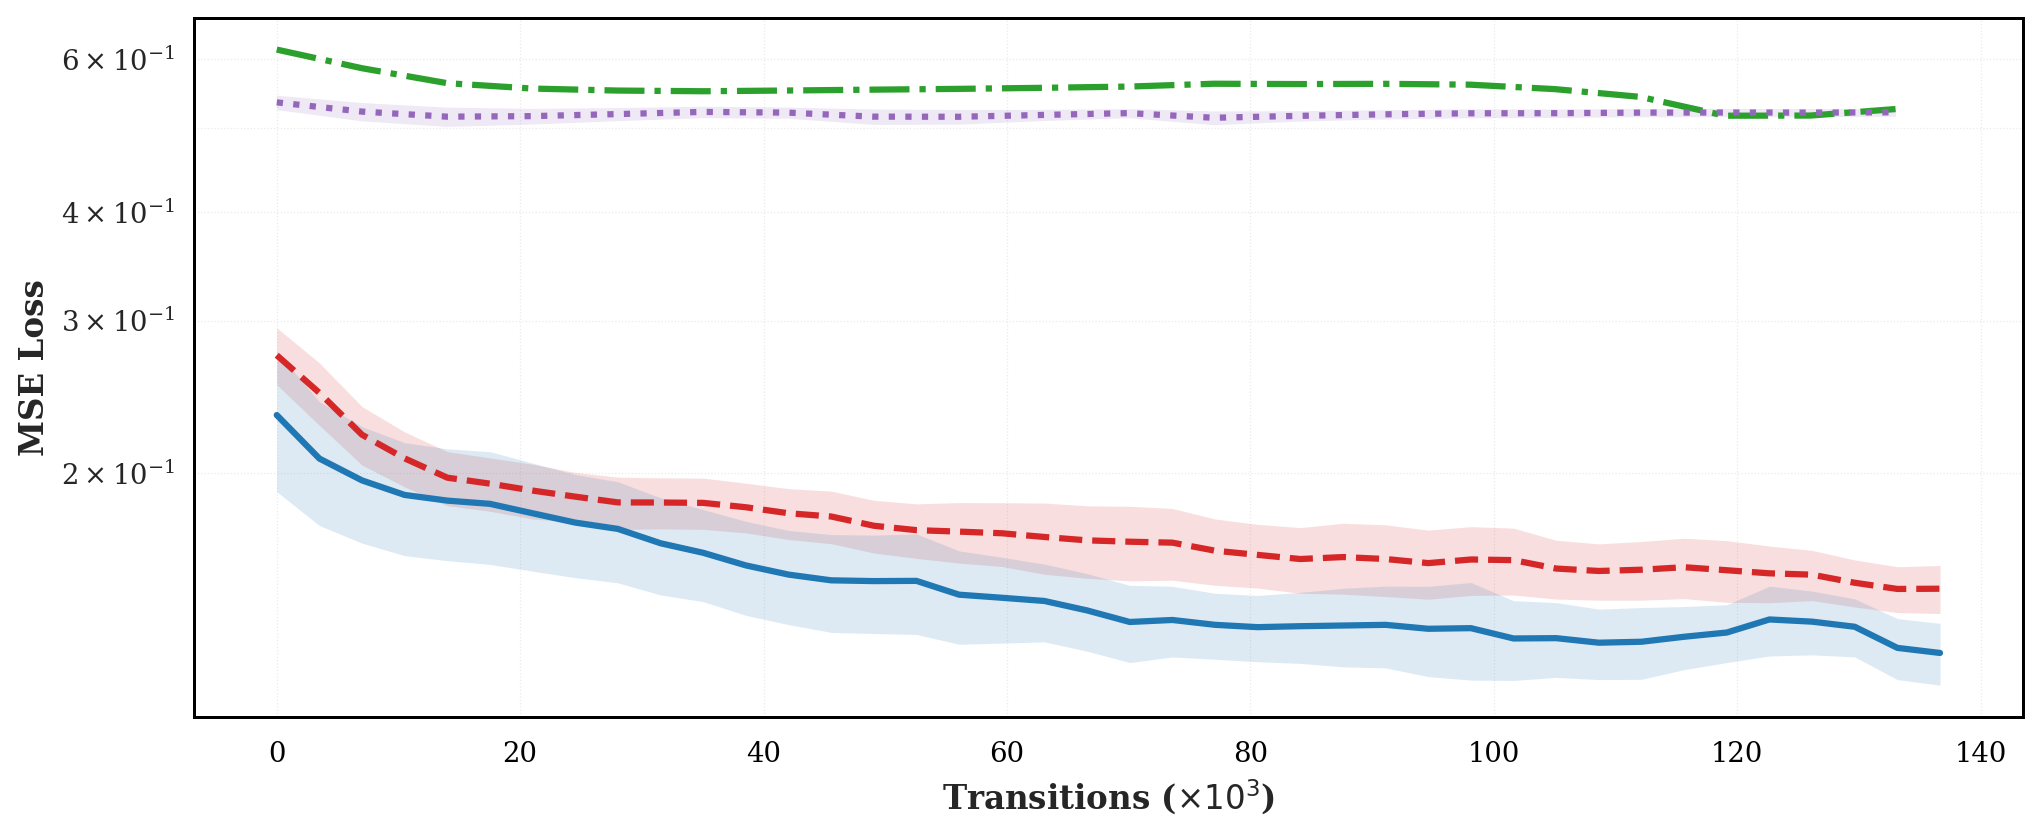

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. 样式与路径配置 (统一下来的大满配风格)
# -----------------------------
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "axes.linewidth": 1.2,
    "figure.dpi": 180,
})

csv_ued_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/minigrid_ued_results_mask3_mse_weighted.csv'
csv_dr_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/dr_summary_minigrid_mask3.csv'
csv_baseline_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_target_baseline/target_baseline_minigrid_mask3.csv'
csv_p2e_path = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/p2e_baseline_minigrid_mask3_n7000_m1_summary.csv'

# -----------------------------
# 2. Helpers (聚合处理，已包含安全的 NaN 验证)
# -----------------------------
def _aggregate_seed_curves(
    df,
    y_cols,
    seed_col='Seed',
    iter_col='Iter',
    warmup_iter=0,
    step_col=None,
    cumulative_col=None,
    x_scale=1000,
    reset_from_first=False,
    recompute_after_warmup=False,
):
    if df is None or len(df) == 0:
        return None

    df = df.copy()

    needed = [seed_col, iter_col]
    for c in y_cols:
        if c in df.columns:
            needed.append(c)
    if step_col and step_col in df.columns:
        needed.append(step_col)
    if cumulative_col and cumulative_col in df.columns:
        needed.append(cumulative_col)

    needed = list(dict.fromkeys(needed))
    df = df[needed].copy()
    df = df.sort_values([seed_col, iter_col])

    per_seed = []
    for seed, g in df.groupby(seed_col):
        g = g.sort_values(iter_col).copy()

        if warmup_iter > 0:
            g = g[pd.to_numeric(g[iter_col], errors='coerce') > warmup_iter].copy()
            if len(g) == 0:
                continue

        if recompute_after_warmup and step_col and step_col in g.columns:
            g['x_raw'] = pd.to_numeric(g[step_col], errors='coerce').cumsum()
        elif cumulative_col and cumulative_col in g.columns:
            g['x_raw'] = pd.to_numeric(g[cumulative_col], errors='coerce')
        elif step_col and step_col in g.columns:
            g['x_raw'] = pd.to_numeric(g[step_col], errors='coerce').cumsum()
        else:
            g['x_raw'] = pd.to_numeric(g[iter_col], errors='coerce')

        if reset_from_first and len(g) > 0:
            g['x_raw'] = g['x_raw'] - g['x_raw'].iloc[0]

        g['x_k'] = g['x_raw'] / x_scale
        g[seed_col] = seed
        per_seed.append(g)

    if len(per_seed) == 0:
        return None

    merged = pd.concat(per_seed, axis=0, ignore_index=True)

    valid_y_cols = [c for c in y_cols if c in merged.columns]
    if len(valid_y_cols) == 0:
        print(f"Warning: none of y_cols={y_cols} found in columns={list(merged.columns)}")
        return None

    for c in valid_y_cols:
        merged[c] = pd.to_numeric(merged[c], errors='coerce')

    agg_dict = {c: ['mean', 'std'] for c in valid_y_cols}
    out = merged.groupby('x_k', as_index=False).agg(agg_dict)

    out.columns = [
        col[0] if col[1] == '' else (col[0] if col[1] == 'mean' else f'{col[0]}_{col[1]}')
        for col in out.columns.to_flat_index()
    ]
    return out


def _load_and_fix_baseline(csv_path):
    if not os.path.exists(csv_path):
        print(f"Warning: baseline file not found: {csv_path}")
        return None, None

    df = pd.read_csv(csv_path).copy()

    cols = df.columns.tolist()
    expected = {
        'Seed', 'Iter', 'Phase', 'Trained_On', 'data_size', 'cumulative_data_size',
        'target_val_val_ce_loss', 'target_val_val_inv_loss', 'target_val_avg_val_loss_wm',
        'Avg_Val_CE', 'Avg_Val_INV', 'Avg_Val_Total'
    }

    if set(cols) >= expected:
        bad_metric = pd.to_numeric(df['target_val_avg_val_loss_wm'], errors='coerce').fillna(0)
        candidate_metric = pd.to_numeric(df['Avg_Val_INV'], errors='coerce')

        if (bad_metric.abs().sum() < 1e-12) and candidate_metric.notna().any():
            print("[Baseline Fix] Detected misaligned baseline CSV. Reconstructing plotting columns.")
            fixed = pd.DataFrame({
                'Seed': 0,
                'Iter': pd.to_numeric(df['Seed'], errors='coerce'),
                'Phase': df['Phase'],
                'Trained_On': df['Phase'],
                'data_size': pd.to_numeric(df['Trained_On'], errors='coerce'),
                'cumulative_data_size': pd.to_numeric(df['data_size'], errors='coerce'),
                'target_val_avg_val_loss_wm': candidate_metric,
            })
            return fixed, 'Iter'

    iter_col = 'Phase' if 'Phase' in df.columns and pd.api.types.is_numeric_dtype(df['Phase']) else 'Iter'
    return df, iter_col


# -----------------------------
# 3. Main Plot
# -----------------------------
def run_minigrid_visualization():
    metric_col = 'target_val_avg_val_loss_wm'

    # DR
    df_dr = None
    if os.path.exists(csv_dr_path):
        df_dr_raw = pd.read_csv(csv_dr_path)
        if 'Seed' in df_dr_raw.columns and 'Iter' in df_dr_raw.columns:
            df_dr_raw = df_dr_raw.drop_duplicates(subset=['Seed', 'Iter'], keep='last')
        df_dr = _aggregate_seed_curves(
            df_dr_raw, y_cols=[metric_col], seed_col='Seed', iter_col='Iter',
            warmup_iter=0, step_col='New_Data_Size', cumulative_col=None,
            x_scale=1000, reset_from_first=True, recompute_after_warmup=False
        )

    # MAC
    df_ued = None
    if os.path.exists(csv_ued_path):
        df_ued_raw = pd.read_csv(csv_ued_path)
        if 'Seed' in df_ued_raw.columns and 'Iter' in df_ued_raw.columns:
            df_ued_raw = df_ued_raw.drop_duplicates(subset=['Seed', 'Iter'], keep='last')
        df_ued = _aggregate_seed_curves(
            df_ued_raw, y_cols=[metric_col], seed_col='Seed', iter_col='Iter',
            warmup_iter=10, step_col='New_Data_Size', cumulative_col=None,
            x_scale=1000, reset_from_first=True, recompute_after_warmup=True
        )

    # Baseline
    df_baseline = None
    df_base_raw, iter_col_base = _load_and_fix_baseline(csv_baseline_path)
    if df_base_raw is not None:
        dedup_cols = [c for c in ['Seed', iter_col_base] if c in df_base_raw.columns]
        if len(dedup_cols) == 2:
            df_base_raw = df_base_raw.drop_duplicates(subset=dedup_cols, keep='last')
        df_baseline = _aggregate_seed_curves(
            df_base_raw, y_cols=[metric_col], seed_col='Seed', iter_col=iter_col_base,
            warmup_iter=0, step_col='data_size' if 'data_size' in df_base_raw.columns else None, 
            cumulative_col='cumulative_data_size' if 'cumulative_data_size' in df_base_raw.columns else None,
            x_scale=1000, reset_from_first=True, recompute_after_warmup=False
        )

    # P2E
    df_p2e = None
    if os.path.exists(csv_p2e_path):
        df_p2e_raw = pd.read_csv(csv_p2e_path).rename(columns={
            'seed': 'Seed', 'avg_target_loss': 'target_val_avg_val_loss_wm', 'transitions': 'Cumulative_Transitions'
        })
        if 'Seed' in df_p2e_raw.columns and 'Iter' in df_p2e_raw.columns:
            df_p2e_raw = df_p2e_raw.drop_duplicates(subset=['Seed', 'Iter'], keep='last')
        df_p2e = _aggregate_seed_curves(
            df_p2e_raw, y_cols=[metric_col], seed_col='Seed', iter_col='Iter',
            warmup_iter=0, step_col=None, cumulative_col='Cumulative_Transitions',
            x_scale=1000, reset_from_first=True, recompute_after_warmup=False
        )

    # --- 开始绘图 (1x1) ---
    fig, ax = plt.subplots(1, 1, figsize=(6.5, 5))

    styles = {
        'DR':       {'df': df_dr,       'color': '#d62728', 'ls': '--', 'label': 'DR'},
        'UED':      {'df': df_ued,      'color': '#1f77b4', 'ls': '-',  'label': 'MAC (Ours)'},
        'Baseline': {'df': df_baseline, 'color': '#2ca02c', 'ls': '-.', 'label': 'Target Baseline'},
        'P2E':      {'df': df_p2e,      'color': '#9467bd', 'ls': ':',  'label': 'P2E'},
    }

    # 同步下来的控制参数
    alpha_ema = 0.6
    std_scale = 0.45

    # 设置边框可见性并加粗
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color('black')
        ax.spines[side].set_linewidth(1.2)

    for name in ['DR', 'UED', 'Baseline', 'P2E']:
        s = styles[name]
        d = s['df']
        if d is None or metric_col not in d.columns:
            continue

        x = pd.to_numeric(d['x_k'], errors='coerce').to_numpy(dtype=float)
        y_raw = pd.to_numeric(d[metric_col], errors='coerce').to_numpy(dtype=float)

        mask = np.isfinite(x) & np.isfinite(y_raw) & (y_raw > 0)
        if mask.sum() == 0:
            continue

        x_m = x[mask]
        y_m = y_raw[mask]

        # 主线平滑
        y_smooth = pd.Series(y_m).ewm(alpha=alpha_ema, adjust=False).mean().values

        ax.plot(
            x_m, y_smooth,
            color=s['color'],
            ls=s['ls'],
            label=s['label'],
            linewidth=2.5,
            zorder=10
        )

        std_col = metric_col + '_std'
        if std_col in d.columns:
            ystd = pd.to_numeric(d[std_col], errors='coerce').fillna(0).to_numpy(dtype=float)[mask]
            
            # 阴影平滑
            ystd_smooth = pd.Series(ystd).ewm(alpha=alpha_ema, adjust=False).mean().values
            
            # 使用 clip 防止误差下界跌破 0 导致 Log scale 报错
            lower = np.clip(y_smooth - ystd_smooth * std_scale, 1e-12, None)
            upper = y_smooth + ystd_smooth * std_scale
            
            ax.fill_between(
                x_m,
                lower,
                upper,
                color=s['color'],
                alpha=0.15,
                lw=0
            )

    # 轴和格式设置
    ax.set_ylabel('MSE Loss', fontweight='bold', fontsize=13)
    ax.set_xlabel(r'Transitions ($\times 10^3$)', fontweight='bold', fontsize=13)
    ax.set_yscale('log')
    import matplotlib.ticker as ticker
    ax.yaxis.set_major_locator(ticker.LogLocator(numticks=6))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}"))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.4)
    ax.tick_params(axis='both', colors='black', width=1.0)
    
    # [这里移除了 ax.legend(...)]

    plt.tight_layout()
    plt.show()

run_minigrid_visualization()


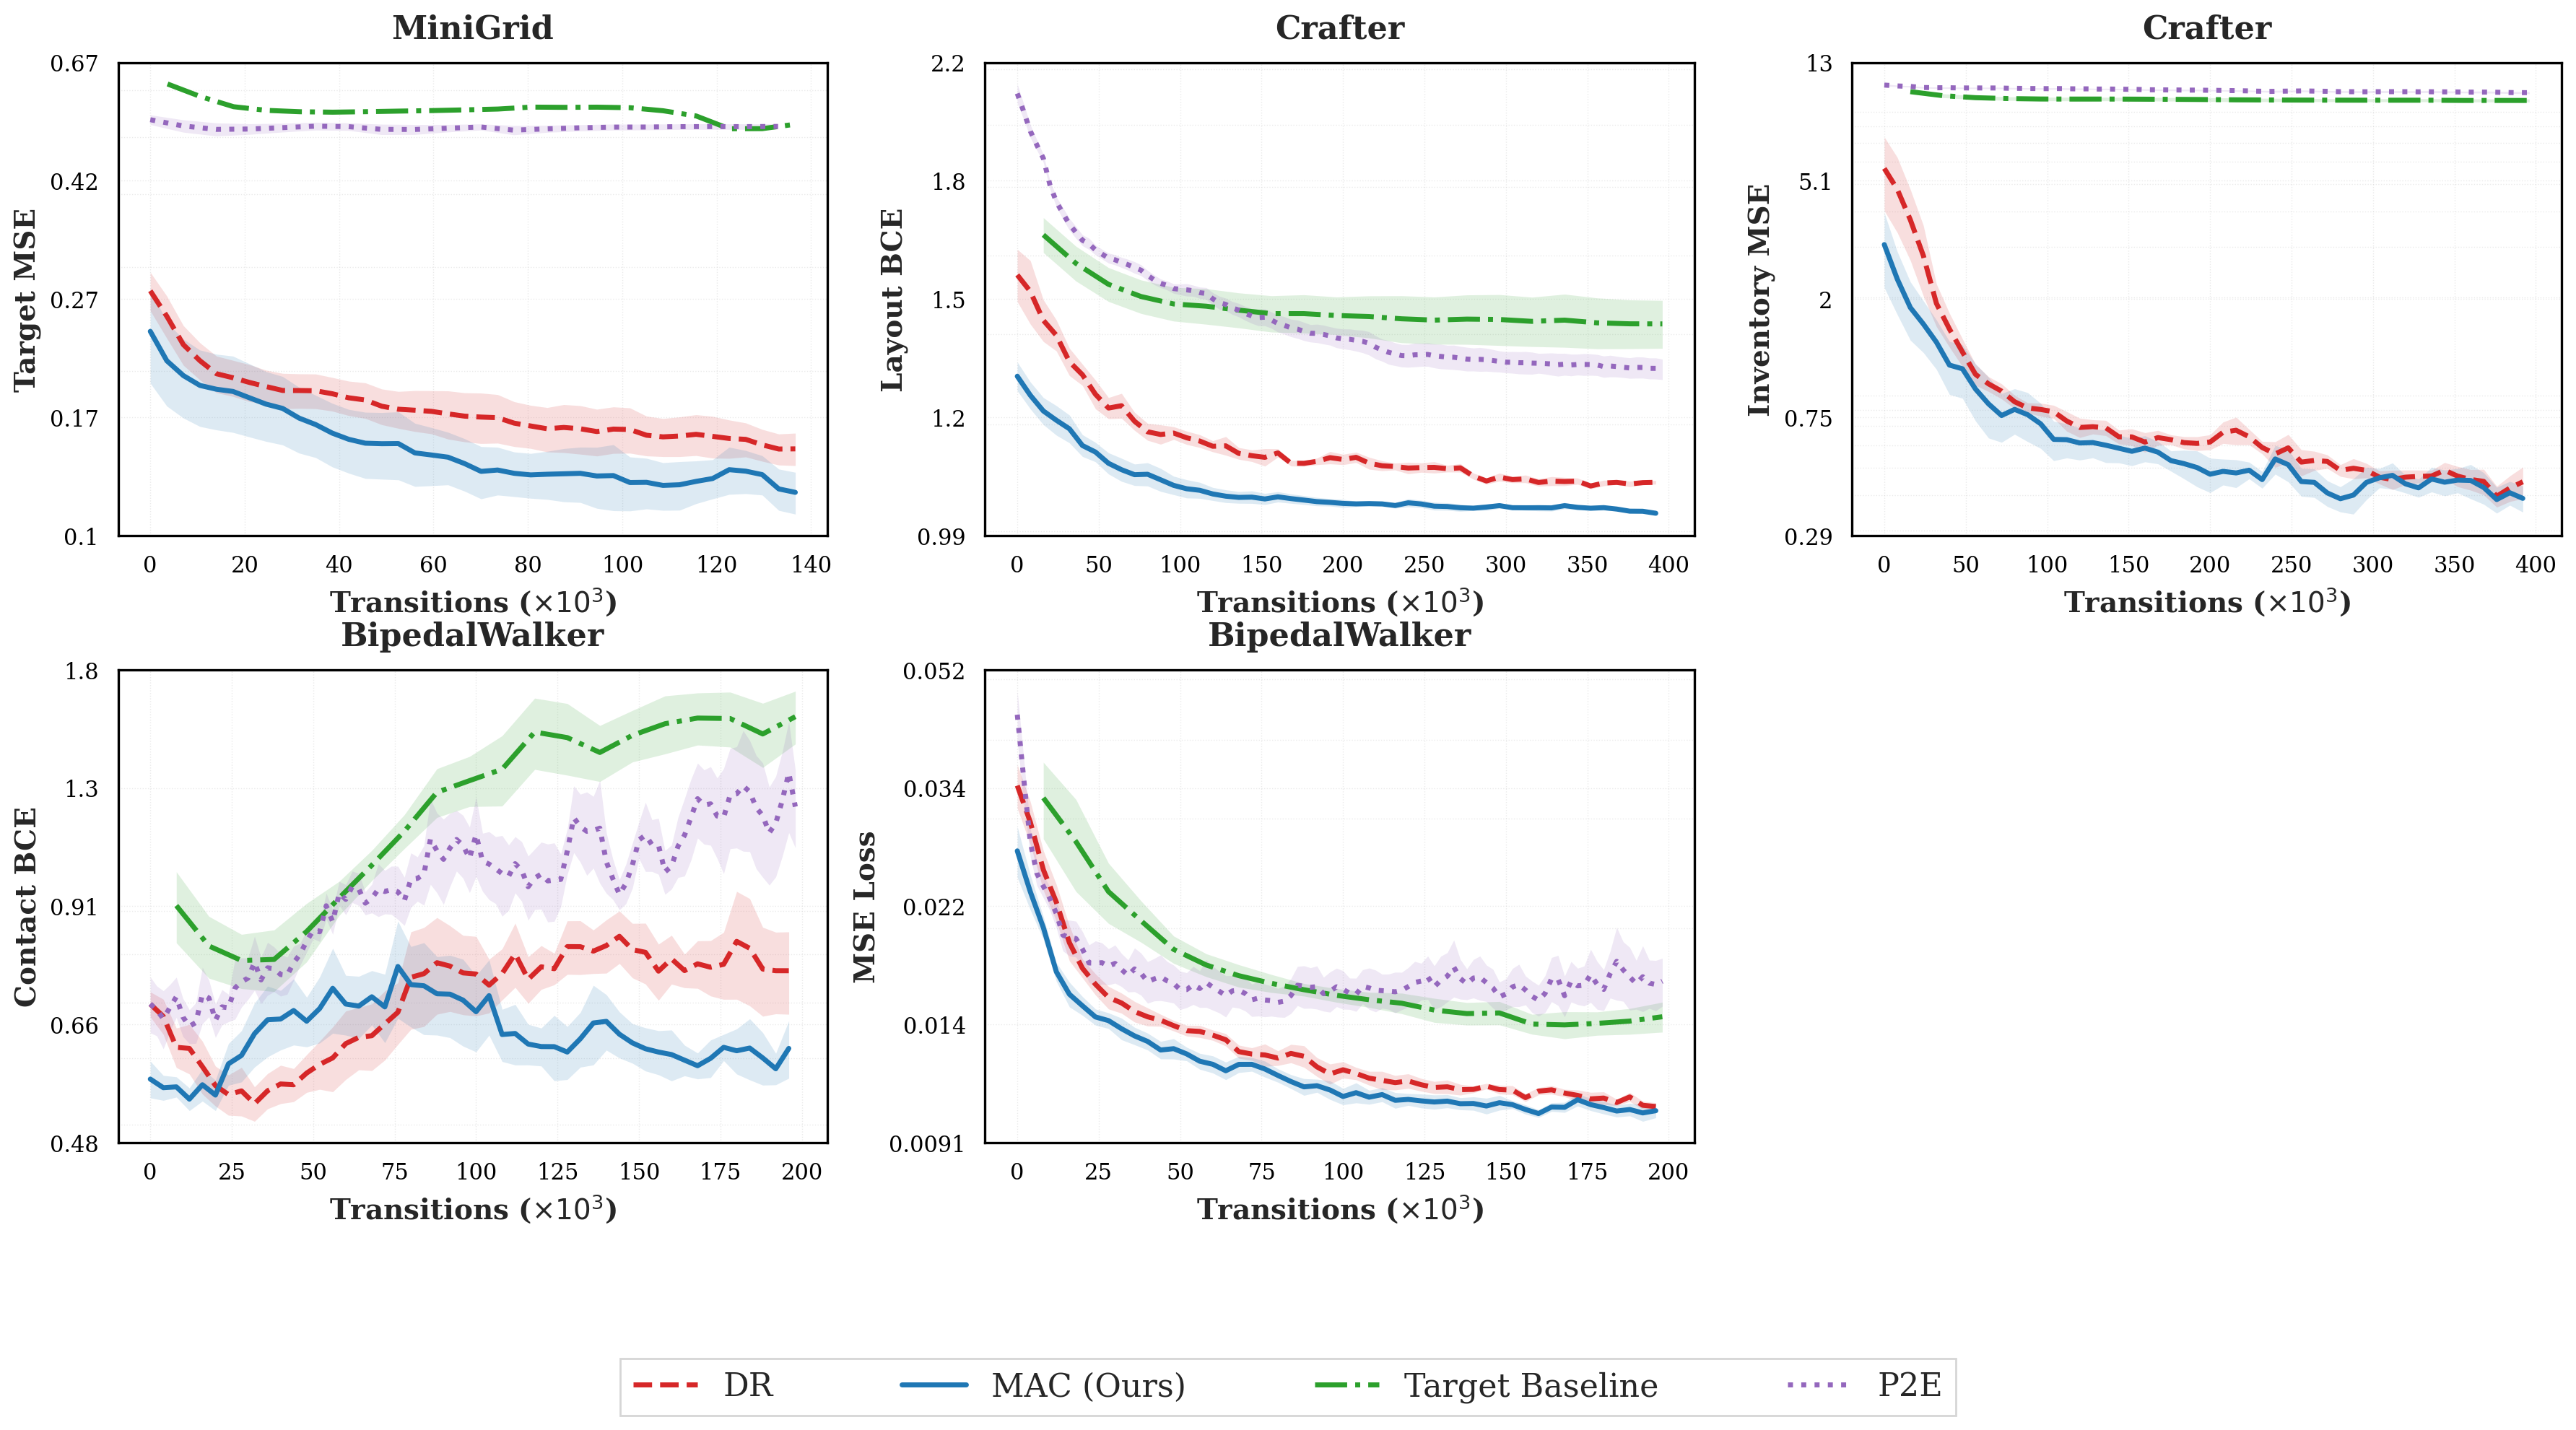

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# ==========================================
# 1. 全局样式配置
# ==========================================
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "axes.linewidth": 1.2,
    "figure.dpi": 200,   
})

BASE_DIR = '/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs'

panels = [
    ('MiniGrid',      'target_val_avg_val_loss_wm',  'MiniGrid',      'Target MSE'),
    ('Crafter',       'target_val_val_ce_loss',      'Crafter',       'Layout BCE'),
    ('Crafter',       'target_val_val_inv_loss',     'Crafter',       'Inventory MSE'),
    ('BipedalWalker', 'target_val_contact_bce',      'BipedalWalker', 'Contact BCE'),
    ('BipedalWalker', 'target_val_avg_val_loss_wm',  'BipedalWalker', 'MSE Loss'),
]

paths = {
    'BipedalWalker': {
        'UED': f'{BASE_DIR}/results/bipedalwalker_ued_results.csv',
        'DR': f'{BASE_DIR}/results_dr/dr_summary_bipedalwalker.csv',
        'BASE': f'{BASE_DIR}/results_target_baseline/target_baseline_bipedalwalker.csv',
        'P2E': f'{BASE_DIR}/p2e_baseline_bipedalwalker_n2000_m5_summary.csv',
    },
    'Crafter': {
        'UED': f'{BASE_DIR}/results/crafter_ued_results_mask5.csv',
        'DR': f'{BASE_DIR}/results_dr/dr_summary_crafter_mask5.csv',
        'BASE': f'{BASE_DIR}/results_target_baseline/crafter_baseline_results.csv',
        'P2E': f'{BASE_DIR}/p2e_baseline_crafter_n4000_m5_summary.csv',
    },
    'MiniGrid': {
        'UED': f'{BASE_DIR}/results/minigrid_ued_results_mask3_mse_weighted.csv',
        'DR': f'{BASE_DIR}/results_dr/dr_summary_minigrid_mask3.csv',
        'BASE': f'{BASE_DIR}/results_target_baseline/target_baseline_minigrid_mask3.csv',
        'P2E': f'{BASE_DIR}/p2e_baseline_minigrid_mask3_n7000_m1_summary.csv',
    }
}

# ==========================================
# 2. 数据处理与聚合函数
# ==========================================
def _aggregate_seed_curves(
    df, y_cols, seed_col='Seed', iter_col='Iter', warmup_iter=0,
    step_col=None, cumulative_col=None, x_scale=1000,
    reset_from_first=False, recompute_after_warmup=False
):
    if df is None or len(df) == 0: return None
    df = df.copy()

    needed = [seed_col, iter_col] + [c for c in y_cols if c in df.columns]
    if step_col and step_col in df.columns: needed.append(step_col)
    if cumulative_col and cumulative_col in df.columns: needed.append(cumulative_col)
    
    needed = list(dict.fromkeys(needed))
    df = df[needed].copy()
    df = df.sort_values([seed_col, iter_col])

    per_seed = []
    for seed, g in df.groupby(seed_col):
        g = g.sort_values(iter_col).copy()

        if warmup_iter > 0:
            g = g[pd.to_numeric(g[iter_col], errors='coerce') > warmup_iter].copy()
            if len(g) == 0: continue

        if recompute_after_warmup and step_col and step_col in g.columns:
            g['x_raw'] = pd.to_numeric(g[step_col], errors='coerce').cumsum()
        elif cumulative_col and cumulative_col in g.columns:
            g['x_raw'] = pd.to_numeric(g[cumulative_col], errors='coerce')
        elif step_col and step_col in g.columns:
            g['x_raw'] = pd.to_numeric(g[step_col], errors='coerce').cumsum()
        else:
            g['x_raw'] = pd.to_numeric(g[iter_col], errors='coerce')

        if reset_from_first and len(g) > 0:
            g['x_raw'] = g['x_raw'] - g['x_raw'].iloc[0]

        g['x_k'] = g['x_raw'] / x_scale
        g[seed_col] = seed
        per_seed.append(g)

    if len(per_seed) == 0: return None
    merged = pd.concat(per_seed, axis=0, ignore_index=True)

    valid_cols = [c for c in y_cols if c in merged.columns]
    if not valid_cols: return None

    for c in valid_cols:
        merged[c] = pd.to_numeric(merged[c], errors='coerce')

    agg_dict = {c: ['mean', 'std'] for c in valid_cols}
    out = merged.groupby('x_k', as_index=False).agg(agg_dict)
    out.columns = [col[0] if col[1] == '' else (col[0] if col[1] == 'mean' else f'{col[0]}_{col[1]}') for col in out.columns.to_flat_index()]
    return out

def _load_baseline_robust(csv_path, domain):
    if not os.path.exists(csv_path): return None, 'Iter'
    df = pd.read_csv(csv_path)
    
    if domain == 'MiniGrid':
        cols = df.columns.tolist()
        expected = {
            'Seed', 'Iter', 'Phase', 'Trained_On', 'data_size', 'cumulative_data_size',
            'target_val_val_ce_loss', 'target_val_val_inv_loss', 'target_val_avg_val_loss_wm',
            'Avg_Val_CE', 'Avg_Val_INV', 'Avg_Val_Total'
        }
        if set(cols) >= expected:
            bad_metric = pd.to_numeric(df['target_val_avg_val_loss_wm'], errors='coerce').fillna(0)
            candidate_metric = pd.to_numeric(df['Avg_Val_INV'], errors='coerce')

            if (bad_metric.abs().sum() < 1e-12) and candidate_metric.notna().any():
                fixed = pd.DataFrame({
                    'Seed': 0,
                    'Iter': pd.to_numeric(df['Seed'], errors='coerce'),
                    'Phase': df['Phase'],
                    'Trained_On': df['Phase'],
                    'data_size': pd.to_numeric(df['Trained_On'], errors='coerce'),
                    'cumulative_data_size': pd.to_numeric(df['data_size'], errors='coerce'),
                    'target_val_avg_val_loss_wm': candidate_metric,
                })
                return fixed, 'Iter'

    iter_c = 'Phase' if ('Phase' in df.columns and pd.api.types.is_numeric_dtype(df['Phase'])) else 'Iter'
    return df, iter_c

# ==========================================
# 3. 预加载全部三个领域的数据
# ==========================================
all_data = {}
for domain, p in paths.items():
    metrics = list(set([pnl[1] for pnl in panels if pnl[0] == domain]))
    all_data[domain] = {}
    
    df_dr_raw = pd.read_csv(p['DR']) if os.path.exists(p['DR']) else None
    if df_dr_raw is not None and 'Seed' in df_dr_raw.columns:
        df_dr_raw = df_dr_raw.drop_duplicates(subset=['Seed', 'Iter'], keep='last')
    all_data[domain]['DR'] = _aggregate_seed_curves(
        df_dr_raw, y_cols=metrics, step_col='New_Data_Size', x_scale=1000, reset_from_first=True
    )

    df_ued_raw = pd.read_csv(p['UED']) if os.path.exists(p['UED']) else None
    if df_ued_raw is not None and 'Seed' in df_ued_raw.columns:
        df_ued_raw = df_ued_raw.drop_duplicates(subset=['Seed', 'Iter'], keep='last')
    all_data[domain]['UED'] = _aggregate_seed_curves(
        df_ued_raw, y_cols=metrics, warmup_iter=10, step_col='New_Data_Size', 
        x_scale=1000, reset_from_first=True, recompute_after_warmup=True
    )

    df_base_raw, iter_col_base = _load_baseline_robust(p['BASE'], domain)
    if df_base_raw is not None:
        dedup_cols = [c for c in ['Seed', iter_col_base] if c in df_base_raw.columns]
        if len(dedup_cols) >= 2:
            df_base_raw = df_base_raw.drop_duplicates(subset=dedup_cols, keep='last')
        all_data[domain]['BASE'] = _aggregate_seed_curves(
            df_base_raw, y_cols=metrics, iter_col=iter_col_base,
            step_col='data_size' if 'data_size' in df_base_raw.columns else None, 
            cumulative_col='cumulative_data_size' if 'cumulative_data_size' in df_base_raw.columns else None,
            x_scale=1000, reset_from_first=True
        )
    else:
        all_data[domain]['BASE'] = None

    df_p2e_raw = pd.read_csv(p['P2E']) if os.path.exists(p['P2E']) else None
    if df_p2e_raw is not None:
        df_p2e_raw = df_p2e_raw.rename(columns={
            'seed': 'Seed', 'avg_target_loss': 'target_val_avg_val_loss_wm', 'transitions': 'Cumulative_Transitions'
        })
        if 'Seed' in df_p2e_raw.columns and 'Iter' in df_p2e_raw.columns:
            df_p2e_raw = df_p2e_raw.drop_duplicates(subset=['Seed', 'Iter'], keep='last')
        all_data[domain]['P2E'] = _aggregate_seed_curves(
            df_p2e_raw, y_cols=metrics, cumulative_col='Cumulative_Transitions', x_scale=1000, reset_from_first=True
        )
    else:
        all_data[domain]['P2E'] = None

# ==========================================
# 4. 组装上 3 下 2 图表 (2x3 网格)
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.delaxes(axes[5]) # 删除第 6 个空白子图

styles = {
    'DR':       {'color': '#d62728', 'ls': '--', 'label': 'DR'},
    'UED':      {'color': '#1f77b4', 'ls': '-',  'label': 'MAC (Ours)'},
    'BASE':     {'color': '#2ca02c', 'ls': '-.', 'label': 'Target Baseline'},
    'P2E':      {'color': '#9467bd', 'ls': ':',  'label': 'P2E'},
}

alpha_ema = 0.6
std_scale = 0.45

for i, (domain, metric_col, title, ylabel) in enumerate(panels):
    ax = axes[i]
    
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color('black')
        ax.spines[side].set_linewidth(1.2)
        
    for name in ['DR', 'UED', 'BASE', 'P2E']:
        s = styles[name]
        d = all_data[domain][name]
        
        if d is None or metric_col not in d.columns: continue

        x = pd.to_numeric(d['x_k'], errors='coerce').to_numpy(dtype=float)
        y_raw = pd.to_numeric(d[metric_col], errors='coerce').to_numpy(dtype=float)

        mask = np.isfinite(x) & np.isfinite(y_raw) & (y_raw > 0)
        if mask.sum() == 0: continue

        x_m = x[mask]
        y_m = y_raw[mask]

        # ======== 自动将 Target Baseline 曲线末端与其他最长曲线末端对齐 ========
        if name == 'BASE':
            max_other_x = 0
            for other_name in ['DR', 'UED', 'P2E']:
                other_d = all_data[domain][other_name]
                if other_d is not None and 'x_k' in other_d.columns:
                    other_x = pd.to_numeric(other_d['x_k'], errors='coerce').to_numpy(dtype=float)
                    if np.any(np.isfinite(other_x)):
                        max_other_x = max(max_other_x, np.nanmax(other_x))
            
            max_base_x = np.nanmax(x_m)
            # 如果存在其他更长的线，且 baseline 有效，则进行右移平移
            if max_other_x > 0 and max_base_x > 0:
                shift = max_other_x - max_base_x
                x_m = x_m + shift
        # ====================================================================

        y_smooth = pd.Series(y_m).ewm(alpha=alpha_ema, adjust=False).mean().values
        ax.plot(x_m, y_smooth, color=s['color'], ls=s['ls'], label=s['label'], linewidth=2.5, zorder=10)

        std_col = metric_col + '_std'
        if std_col in d.columns:
            ystd = pd.to_numeric(d[std_col], errors='coerce').fillna(0).to_numpy(dtype=float)[mask]
            ystd_smooth = pd.Series(ystd).ewm(alpha=alpha_ema, adjust=False).mean().values
            lower = np.clip(y_smooth - ystd_smooth * std_scale, 1e-12, None)
            upper = y_smooth + ystd_smooth * std_scale
            ax.fill_between(x_m, lower, upper, color=s['color'], alpha=0.15, lw=0)

    ax.set_title(title, fontweight='bold', fontsize=16, pad=12)
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=14)
    ax.set_xlabel(r"Transitions ($\times 10^3$)", fontweight='bold', fontsize=14)
    ax.set_yscale('log')
    
    ymin, ymax = ax.get_ylim()
    if ymin < ymax:
        ticks = np.logspace(np.log10(ymin), np.log10(ymax), num=5)
        ax.set_yticks(ticks)
    
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:.2g}"))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    
    ax.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.4)
    ax.tick_params(axis='both', colors='black', width=1.0)

# ==========================================
# 5. 生成底部悬浮的横向大图例
# ==========================================
plt.tight_layout()

fig.subplots_adjust(bottom=0.20)
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles, labels, 
    loc='lower center',           
    bbox_to_anchor=(0.5, 0.0),    
    ncol=4,                       
    frameon=True,                 
    fancybox=False,               
    edgecolor='0.8',              
    fontsize=16,                  
    columnspacing=4.0             
)

plt.show()


[Load] /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/dr_summary_minigrid_mask3.csv
[Load] /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/dr_summary_minigrid_mask3_p2e.csv
[Load] /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/minigrid_ued_results_mask3_mse_weighted.csv
[Load] /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/minigrid_ued_results_mask3_mse_weighted_p2e_within2.csv
[Load] /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_target_baseline/target_baseline_minigrid_mask3.csv
[Load] /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/p2e_baseline_minigrid_mask3_n7000_m1_summary.csv


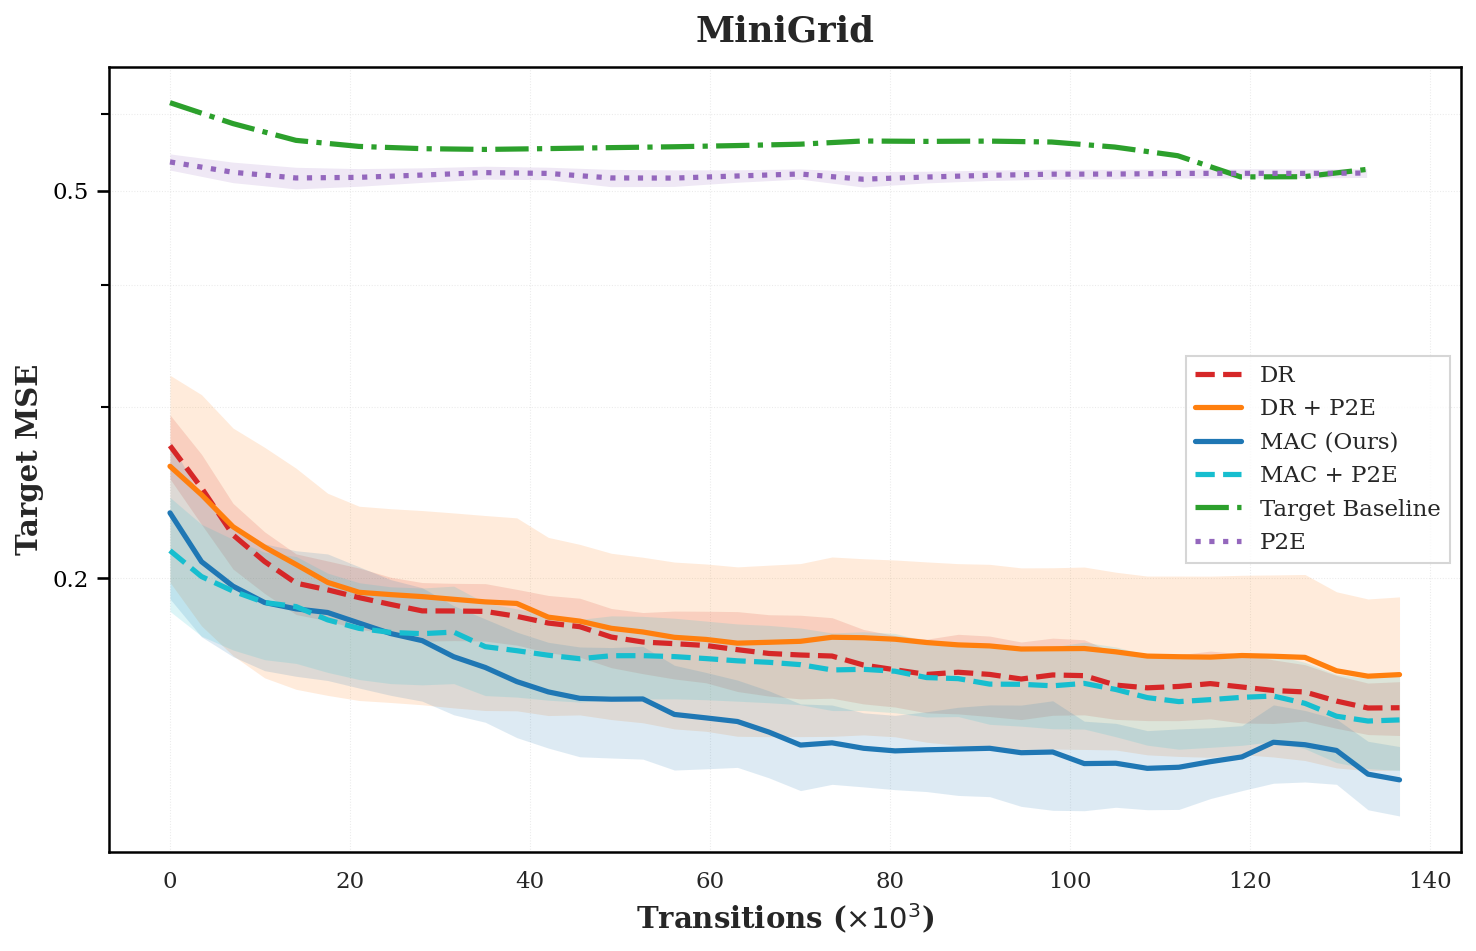

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

%matplotlib inline

# ============================================================
# MiniGrid: MAC / MAC+P2E / DR / DR+P2E / Target Baseline / P2E
# ============================================================

BASE_DIR = (
    "/home/siyao/phd_file/Research/rlPractice/"
    "Curriculum_world_model_learning/trainer/logs"
)

METRIC = "target_val_avg_val_loss_wm"

paths = {
    "DR": f"{BASE_DIR}/results_dr/dr_summary_minigrid_mask3.csv",
    "DR_P2E": f"{BASE_DIR}/results_dr/dr_summary_minigrid_mask3_p2e.csv",
    "UED": f"{BASE_DIR}/results/minigrid_ued_results_mask3_mse_weighted.csv",
    "UED_P2E": f"{BASE_DIR}/results/minigrid_ued_results_mask3_mse_weighted_p2e_within2.csv",
    "BASE": (
        f"{BASE_DIR}/results_target_baseline/"
        "target_baseline_minigrid_mask3.csv"
    ),
    "P2E": (
        f"{BASE_DIR}/"
        "p2e_baseline_minigrid_mask3_n7000_m1_summary.csv"
    ),
}


def load_csv(path):
    if not os.path.exists(path):
        print(f"[Missing] {path}")
        return None

    print(f"[Load] {path}")
    return pd.read_csv(path)


def aggregate_seed_curves(
    df,
    iter_col="Iter",
    warmup_iter=0,
    step_col=None,
    cumulative_col=None,
    recompute_after_warmup=False,
):
    """Aggregate mean/std across seeds using transitions as x-axis."""

    if df is None or len(df) == 0:
        return None

    df = df.rename(columns={"seed": "Seed"}).copy()

    required = {"Seed", iter_col, METRIC}
    if not required.issubset(df.columns):
        print(f"[Skip] Missing columns: {required - set(df.columns)}")
        return None

    keep = ["Seed", iter_col, METRIC]

    if step_col and step_col in df.columns:
        keep.append(step_col)

    if cumulative_col and cumulative_col in df.columns:
        keep.append(cumulative_col)

    df = df[list(dict.fromkeys(keep))].copy()
    df = df.drop_duplicates(
        subset=["Seed", iter_col],
        keep="last",
    )

    per_seed = []

    for seed, group in df.groupby("Seed"):
        group = group.sort_values(iter_col).copy()
        group[iter_col] = pd.to_numeric(
            group[iter_col],
            errors="coerce",
        )

        if warmup_iter > 0:
            group = group[group[iter_col] > warmup_iter].copy()

        if len(group) == 0:
            continue

        if (
            recompute_after_warmup
            and step_col
            and step_col in group.columns
        ):
            x_raw = pd.to_numeric(
                group[step_col],
                errors="coerce",
            ).cumsum()

        elif (
            cumulative_col
            and cumulative_col in group.columns
        ):
            x_raw = pd.to_numeric(
                group[cumulative_col],
                errors="coerce",
            )

        elif step_col and step_col in group.columns:
            x_raw = pd.to_numeric(
                group[step_col],
                errors="coerce",
            ).cumsum()

        else:
            x_raw = group[iter_col]

        # Start every seed from transition 0.
        group["x_k"] = (
            x_raw - x_raw.iloc[0]
        ) / 1000.0

        group[METRIC] = pd.to_numeric(
            group[METRIC],
            errors="coerce",
        )

        group["Seed"] = seed
        per_seed.append(group)

    if len(per_seed) == 0:
        return None

    merged = pd.concat(per_seed, ignore_index=True)

    result = (
        merged.groupby("x_k")[METRIC]
        .agg(["mean", "std"])
        .reset_index()
        .rename(
            columns={
                "mean": METRIC,
                "std": f"{METRIC}_std",
            }
        )
    )

    return result


def load_target_baseline(path):
    """Load normal or historical MiniGrid baseline schema."""

    df = load_csv(path)

    if df is None:
        return None, "Iter"

    expected = {
        "Seed",
        "Iter",
        "Phase",
        "Trained_On",
        "data_size",
        "cumulative_data_size",
        METRIC,
        "Avg_Val_INV",
    }

    if expected.issubset(df.columns):
        target = pd.to_numeric(
            df[METRIC],
            errors="coerce",
        ).fillna(0)

        candidate = pd.to_numeric(
            df["Avg_Val_INV"],
            errors="coerce",
        )

        # Repair historical shifted-column format.
        if (
            target.abs().sum() < 1e-12
            and candidate.notna().any()
        ):
            fixed = pd.DataFrame(
                {
                    "Seed": 0,
                    "Iter": pd.to_numeric(
                        df["Seed"],
                        errors="coerce",
                    ),
                    "data_size": pd.to_numeric(
                        df["Trained_On"],
                        errors="coerce",
                    ),
                    "cumulative_data_size": pd.to_numeric(
                        df["data_size"],
                        errors="coerce",
                    ),
                    METRIC: candidate,
                }
            )

            return fixed, "Iter"

    iter_col = (
        "Phase"
        if (
            "Phase" in df.columns
            and pd.api.types.is_numeric_dtype(df["Phase"])
        )
        else "Iter"
    )

    return df, iter_col


# ============================================================
# Load and aggregate curves
# ============================================================

curves = {}

# DR
curves["DR"] = aggregate_seed_curves(
    load_csv(paths["DR"]),
    step_col="New_Data_Size",
)

# DR + P2E
curves["DR_P2E"] = aggregate_seed_curves(
    load_csv(paths["DR_P2E"]),
    step_col="New_Data_Size",
)

# MAC / UED: remove the first 10 warmup iterations.
curves["UED"] = aggregate_seed_curves(
    load_csv(paths["UED"]),
    warmup_iter=10,
    step_col="New_Data_Size",
    recompute_after_warmup=True,
)

# MAC + P2E: plot the 40 post-warmup points at Iter 6-45.
# Iter 6 is aligned to transition 0 for every seed.
ued_p2e_df = load_csv(paths["UED_P2E"])
if ued_p2e_df is not None:
    ued_p2e_iter = pd.to_numeric(ued_p2e_df["Iter"], errors="coerce")
    ued_p2e_df = ued_p2e_df[ued_p2e_iter.between(6, 45)].copy()

curves["UED_P2E"] = aggregate_seed_curves(
    ued_p2e_df,
    step_col="New_Data_Size",
    recompute_after_warmup=True,
)

# Target baseline
baseline_df, baseline_iter_col = load_target_baseline(
    paths["BASE"]
)

curves["BASE"] = aggregate_seed_curves(
    baseline_df,
    iter_col=baseline_iter_col,
    step_col="data_size",
    cumulative_col="cumulative_data_size",
)

# Standalone P2E
p2e_df = load_csv(paths["P2E"])

if p2e_df is not None:
    p2e_df = p2e_df.rename(
        columns={
            "seed": "Seed",
            "avg_target_loss": METRIC,
            "transitions": "Cumulative_Transitions",
        }
    )

curves["P2E"] = aggregate_seed_curves(
    p2e_df,
    cumulative_col="Cumulative_Transitions",
)


# ============================================================
# Plot — display only, do not save
# ============================================================

sns.set_theme(style="whitegrid")

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": [
            "Times New Roman",
            "DejaVu Serif",
            "serif",
        ],
        "axes.linewidth": 1.2,
        "figure.dpi": 150,
    }
)

styles = {
    "DR": {
        "color": "#d62728",
        "ls": "--",
        "label": "DR",
    },
    "DR_P2E": {
        "color": "#ff7f0e",
        "ls": "-",
        "label": "DR + P2E",
    },
    "UED": {
        "color": "#1f77b4",
        "ls": "-",
        "label": "MAC (Ours)",
    },
    "UED_P2E": {
        "color": "#17becf",
        "ls": "--",
        "label": "MAC + P2E",
    },
    "BASE": {
        "color": "#2ca02c",
        "ls": "-.",
        "label": "Target Baseline",
    },
    "P2E": {
        "color": "#9467bd",
        "ls": ":",
        "label": "P2E",
    },
}

fig, ax = plt.subplots(figsize=(10, 6.5))

alpha_ema = 0.6
std_scale = 0.45

for name in [
    "DR",
    "DR_P2E",
    "UED",
    "UED_P2E",
    "BASE",
    "P2E",
]:
    data = curves.get(name)

    if data is None or METRIC not in data.columns:
        continue

    x = pd.to_numeric(
        data["x_k"],
        errors="coerce",
    ).to_numpy(dtype=float)

    y = pd.to_numeric(
        data[METRIC],
        errors="coerce",
    ).to_numpy(dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & (y > 0)
    )

    if valid.sum() == 0:
        continue

    x = x[valid]
    y = y[valid]

    y_smooth = (
        pd.Series(y)
        .ewm(alpha=alpha_ema, adjust=False)
        .mean()
        .to_numpy()
    )

    style = styles[name]

    ax.plot(
        x,
        y_smooth,
        color=style["color"],
        linestyle=style["ls"],
        label=style["label"],
        linewidth=2.5,
        zorder=10,
    )

    std_col = f"{METRIC}_std"

    if std_col in data.columns:
        y_std = (
            pd.to_numeric(
                data[std_col],
                errors="coerce",
            )
            .fillna(0)
            .to_numpy(dtype=float)[valid]
        )

        y_std_smooth = (
            pd.Series(y_std)
            .ewm(alpha=alpha_ema, adjust=False)
            .mean()
            .to_numpy()
        )

        lower = np.clip(
            y_smooth - y_std_smooth * std_scale,
            1e-12,
            None,
        )

        upper = (
            y_smooth
            + y_std_smooth * std_scale
        )

        ax.fill_between(
            x,
            lower,
            upper,
            color=style["color"],
            alpha=0.15,
            linewidth=0,
        )


for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.2)

ax.set_title(
    "MiniGrid",
    fontsize=17,
    fontweight="bold",
    pad=12,
)

ax.set_xlabel(
    r"Transitions ($\times 10^3$)",
    fontsize=14,
    fontweight="bold",
)

ax.set_ylabel(
    "Target MSE",
    fontsize=14,
    fontweight="bold",
)

ax.set_yscale("log")

ax.yaxis.set_major_locator(
    ticker.LogLocator(
        base=10,
        subs=(1.0, 2.0, 5.0),
        numticks=20,
    )
)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda value, _: f"{value:.3g}"
    )
)

ax.yaxis.set_minor_formatter(
    ticker.NullFormatter()
)
ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")
ax.tick_params(
    axis="y",
    which="both",
    left=True,
    labelleft=True,
    labelsize=11,
    colors="black",
)

ax.grid(
    True,
    which="both",
    linestyle=":",
    linewidth=0.5,
    alpha=0.4,
)

ax.legend(
    loc="center right",
    frameon=True,
    fancybox=False,
    edgecolor="0.8",
    fontsize=11,
)

plt.tight_layout()
plt.show()

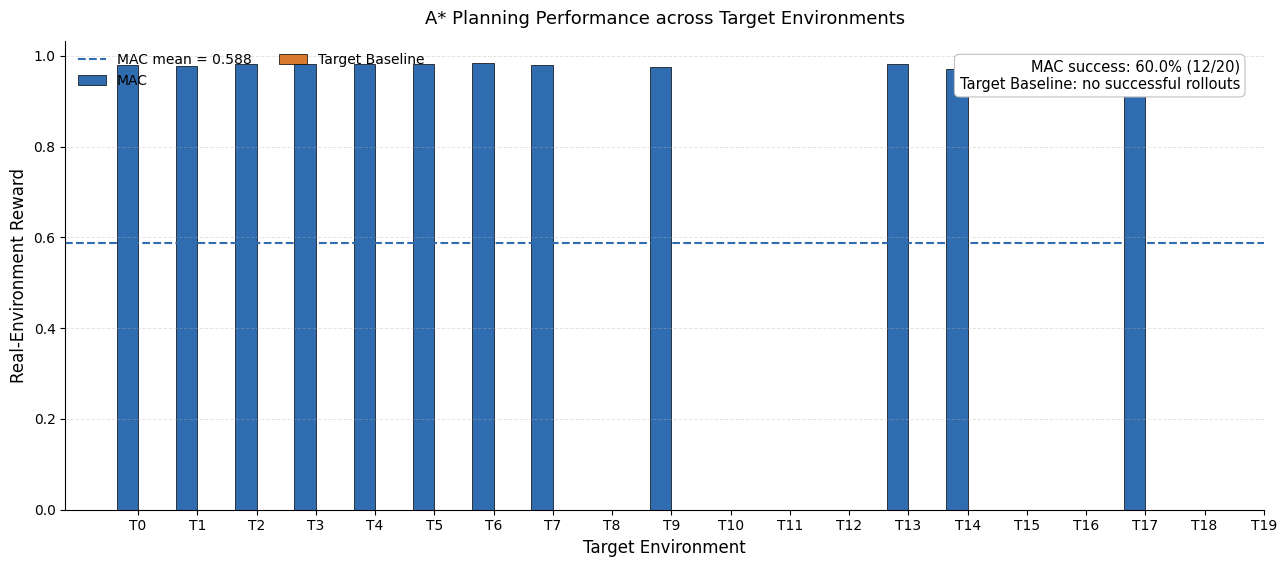

MAC success rate: 60.0%
Target Baseline success rate: 0.0%
MAC mean reward: 0.588
Target mean reward: 0.000
Saved to: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/wm/outputs/planning/target_astar_result/aamas_style_mac_vs_target_astar_reward.png


In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =============================
# 1. 路径
# =============================

PROJECT_ROOT = Path(
    "/home/siyao/phd_file/Research/rlPractice/"
    "Curriculum_world_model_learning"
)

MAC_DIR = PROJECT_ROOT / "wm/outputs/planning/mac_astar_results"
TARGET_DIR = PROJECT_ROOT / "wm/outputs/planning/target_astar_result"

mac_csv = MAC_DIR / "wm_planner_results.csv"
target_csv = TARGET_DIR / "wm_planner_results.csv"


# =============================
# 2. 读取和整理数据
# =============================

def load_results(csv_path):
    df = pd.read_csv(csv_path).copy()

    df["target_id"] = (
        df["target"]
        .astype(str)
        .str.extract(r"(\d+)", expand=False)
        .astype(int)
    )

    df["real_reward"] = pd.to_numeric(
        df["real_reward"],
        errors="coerce",
    ).fillna(0)

    df["success"] = (
        df["real_reached_goal"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("true")
    )

    return df.sort_values("target_id")


mac_df = load_results(mac_csv)
target_df = load_results(target_csv)

targets = [f"target_task{i}" for i in range(20)]

mac_df = (
    mac_df
    .set_index("target")
    .reindex(targets)
)

target_df = (
    target_df
    .set_index("target")
    .reindex(targets)
)

mac_reward = mac_df["real_reward"].fillna(0).to_numpy()
target_reward = target_df["real_reward"].fillna(0).to_numpy()

mac_success = mac_df["success"].fillna(False).to_numpy()
target_success = target_df["success"].fillna(False).to_numpy()

mac_success_rate = mac_success.mean() * 100
target_success_rate = target_success.mean() * 100

mac_mean_reward = mac_reward.mean()
target_mean_reward = target_reward.mean()


# =============================
# 3. 失败不显示柱子
# =============================

mac_plot_reward = np.where(
    mac_success,
    mac_reward,
    np.nan,
)

target_plot_reward = np.where(
    target_success,
    target_reward,
    np.nan,
)


# =============================
# 4. AAMAS 风格绘图
# =============================

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "DejaVu Sans",
})

fig, ax = plt.subplots(figsize=(13, 5.8))

x = np.arange(len(targets))
width = 0.36

mac_color = "#2F6DB0"
target_color = "#D9792B"

ax.bar(
    x - width / 2,
    mac_plot_reward,
    width=width,
    color=mac_color,
    edgecolor="black",
    linewidth=0.5,
    label="MAC",
)

ax.bar(
    x + width / 2,
    target_plot_reward,
    width=width,
    color=target_color,
    edgecolor="black",
    linewidth=0.5,
    label="Target Baseline",
)


# =============================
# 5. 平均 reward 线
# =============================

if mac_mean_reward > 0:
    ax.axhline(
        mac_mean_reward,
        color=mac_color,
        linestyle="--",
        linewidth=1.5,
        label=f"MAC mean = {mac_mean_reward:.3f}",
    )

if target_mean_reward > 0:
    ax.axhline(
        target_mean_reward,
        color=target_color,
        linestyle=":",
        linewidth=1.5,
        label=f"Target mean = {target_mean_reward:.3f}",
    )


# =============================
# 6. 成功率和结果说明
# =============================

target_note = (
    "Target Baseline: no successful rollouts"
    if target_success_rate == 0
    else f"Target Baseline: {target_success_rate:.1f}% success"
)

ax.text(
    0.98,
    0.96,
    f"MAC success: {mac_success_rate:.1f}% "
    f"({int(mac_success.sum())}/20)\n"
    f"{target_note}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10.5,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.75",
        linewidth=0.8,
    ),
)


# =============================
# 7. 坐标轴和版式
# =============================

ax.set_xlabel("Target Environment")
ax.set_ylabel("Real-Environment Reward")

ax.set_xticks(x)
ax.set_xticklabels([f"T{i}" for i in range(20)])

ax.set_title(
    "A* Planning Performance across Target Environments",
    pad=12,
)

ax.set_ylim(bottom=0)
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.35,
)

# 论文图中通常去掉上、右边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper left",
    frameon=False,
    ncol=2,
)

plt.tight_layout()


# =============================
# 8. 保存
# =============================

figure_path = (
    TARGET_DIR
    / "aamas_style_mac_vs_target_astar_reward.png"
)

plt.savefig(
    figure_path,
    dpi=400,
    bbox_inches="tight",
)

plt.show()

print(f"MAC success rate: {mac_success_rate:.1f}%")
print(f"Target Baseline success rate: {target_success_rate:.1f}%")
print(f"MAC mean reward: {mac_mean_reward:.3f}")
print(f"Target mean reward: {target_mean_reward:.3f}")
print(f"Saved to: {figure_path}")

DR seeds: [0, 1, 2]
MAC seeds: [0]
             min  max  count
Method Seed                 
DR     0       1   50     50
       1       1   50     50
       2       1   50     50
MAC    0       1   50     50


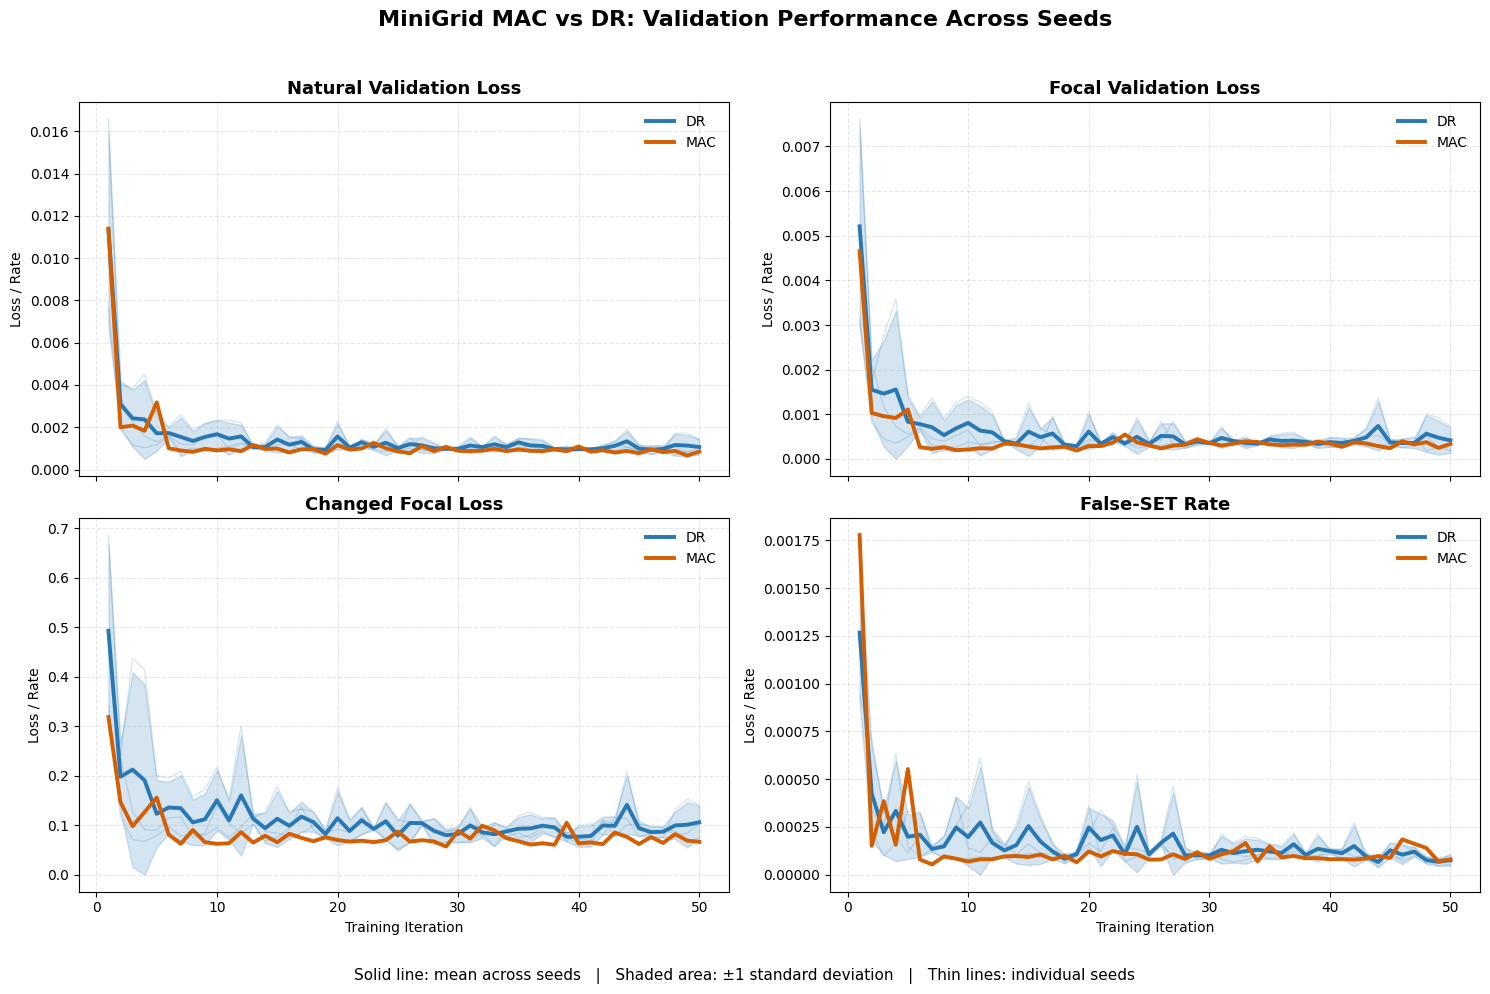

Figure saved to:
/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/outputs/results/mac_dr_validation_mean_std.png


,Method,Seed,Iter,target_val_avg_val_loss_wm,target_val_focal_loss,target_val_changed_focal_loss,target_val_false_set_rate
49,DR,0,50,0.001067,0.000335,0.074542,0.000108
99,DR,1,50,0.000711,0.000184,0.102993,0.000066
149,DR,2,50,0.001423,0.000730,0.140674,0.000054
199,MAC,0,50,0.000852,0.000337,0.066472,0.000081


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 文件路径
# =========================
PROJECT_ROOT = Path(
    "/home/siyao/phd_file/Research/rlPractice/"
    "Curriculum_world_model_learning"
)

DR_PATH = (
    PROJECT_ROOT
    / "outputs/results/dr/"
    / "dr_summary_minigrid_mask5_focal_reservoir.csv"
)

MAC_PATH = (
    PROJECT_ROOT
    / "outputs/results/mac/"
    / "minigrid_ued_results_mask5_focal_reservoir_sa.csv"
)

# =========================
# 2. 读取并整理数据
# =========================
def load_results(path, method_name, warmup_iter=0):
    df = pd.read_csv(path)

    df["Seed"] = pd.to_numeric(df["Seed"], errors="coerce")
    df["Iter"] = pd.to_numeric(df["Iter"], errors="coerce")

    metrics = ["target_val_changed_focal_loss"]

    for col in metrics:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["Seed", "Iter"])

    # Warmup rows use zero as a placeholder when target validation is skipped.
    # Exclude them instead of treating them as genuine zero changed-focal loss.
    if "target_val_valid_count" in df.columns:
        valid_count = pd.to_numeric(df["target_val_valid_count"], errors="coerce")
        df = df[valid_count > 0].copy()
    df = df.dropna(subset=["target_val_changed_focal_loss"])

    # 防止同一个 seed/iteration 被重复粘贴
    df = (
        df.sort_values(["Seed", "Iter"])
          .drop_duplicates(["Seed", "Iter"], keep="last")
    )

    # Compare effective training progress: DR starts at Iter 1, while MAC
    # starts immediately after its 10-round warmup (Iter 11).
    df = df[df["Iter"] > warmup_iter].copy()
    df["Aligned_Iter"] = df.groupby("Seed").cumcount()

    df["Method"] = method_name
    return df


dr = load_results(DR_PATH, "DR", warmup_iter=0)
mac = load_results(MAC_PATH, "MAC", warmup_iter=10)

all_data = pd.concat([dr, mac], ignore_index=True)

print("DR seeds:", sorted(dr["Seed"].unique()))
print("MAC seeds:", sorted(mac["Seed"].unique()))
print(
    all_data.groupby(["Method", "Seed"])
    .agg(
        original_iter_min=("Iter", "min"),
        original_iter_max=("Iter", "max"),
        aligned_start=("Aligned_Iter", "min"),
        aligned_end=("Aligned_Iter", "max"),
        count=("Aligned_Iter", "count"),
    )
)


# =========================
# 3. 绘制多 seed mean ± std
# =========================
metrics = ["target_val_changed_focal_loss"]

titles = {
    "target_val_avg_val_loss_wm": "Natural Validation Loss",
    "target_val_focal_loss": "Focal Validation Loss",
    "target_val_changed_focal_loss": "Changed Focal Loss",
    "target_val_false_set_rate": "False-SET Rate",
}

colors = {
    "DR": "#2878B5",
    "MAC": "#D55E00",
}
line_styles = {"DR": "-", "MAC": "--"}
markers = {"DR": "o", "MAC": "s"}

fig, ax = plt.subplots(figsize=(9, 5.5))
axes = [ax]

for ax, metric in zip(axes, metrics):

    for method in ["DR", "MAC"]:
        method_df = all_data[all_data["Method"] == method]

        if method_df.empty:
            continue

        color = colors[method]

        # 每个 seed 的浅色曲线
        for seed, seed_df in method_df.groupby("Seed"):
            seed_df = seed_df.sort_values("Aligned_Iter")

            ax.plot(
                seed_df["Aligned_Iter"],
                seed_df[metric],
                color=color,
                alpha=0.10,
                linewidth=0.65,
            )

        # 多 seed 均值和标准差
        stats = (
            method_df.groupby("Aligned_Iter")[metric]
            .agg(["mean", "std"])
            .reset_index()
            .sort_values("Aligned_Iter")
        )

        stats["std"] = stats["std"].fillna(0.0)

        x = stats["Aligned_Iter"].to_numpy()
        mean = stats["mean"].to_numpy()
        std = stats["std"].to_numpy()

        lower = np.maximum(mean - std, 0.0)
        upper = mean + std

        ax.plot(
            x,
            mean,
            color=color,
            linestyle=line_styles[method],
            linewidth=1.8,
            marker=markers[method],
            markevery=5,
            markersize=4.0,
            label=f"{method} (n={method_df['Seed'].nunique()} seeds)",
        )

        ax.fill_between(
            x,
            lower,
            upper,
            color=color,
            alpha=0.12,
        )

    ax.set_title(titles[metric], fontsize=13, fontweight="bold")
    ax.set_ylabel("Target changed-focal loss")
    ax.set_xlabel("Aligned training iteration (MAC post-warmup = 0)")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(frameon=False)

fig.suptitle(
    "MiniGrid MAC vs DR: Changed-Focal Loss Across Seeds",
    fontsize=16,
    fontweight="bold",
)

fig.text(
    0.5,
    0.01,
    "Solid line: mean across seeds   |   Shaded area: ±1 standard deviation   "
    "|   Thin lines: individual seeds",
    ha="center",
    fontsize=11,
)

plt.tight_layout(rect=[0, 0.04, 1, 0.96])

FIGURE_PATH = (
    PROJECT_ROOT
    / "outputs/results/"
    / "mac_dr_changed_focal_across_seeds.png"
)

plt.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to:\n{FIGURE_PATH}")


# =========================
# 4. 打印每个 seed 的最后一轮结果
# =========================
last_results = (
    all_data.sort_values(["Method", "Seed", "Iter"])
    .groupby(["Method", "Seed"])
    .tail(1)
)

display(
    last_results[
        [
            "Method",
            "Seed",
            "Iter",
            "Aligned_Iter",
            "target_val_changed_focal_loss",
        ]
    ].sort_values(["Method", "Seed"])
)
